# Accumulated-phase spectroscopy across pulse duration

This notebook repeats the full qutrit analysis of notebook 34 for pulse lengths $L=3,5,7,10,20,30~\mu\mathrm{s}$. Every duration uses cutoff $c=0.001$, $\beta=0$, the paper coherence defaults, and an independently optimized accumulated-phase coefficient $\kappa$. Complete population maps and extracted metrics are cached as compressed NPZ data and assembled into a self-contained tabbed HTML report.

In [1]:
import csv
from html import escape
from pathlib import Path
import subprocess
import sys

from IPython.display import HTML, Image, Markdown, display

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
GENERATOR = PROJECT_ROOT / 'scripts' / 'make_accumulated_phase_duration_report.py'
DATA_DIR = PROJECT_ROOT / 'data' / 'generated' / 'accumulated_phase_duration_sweep'
FIGURE_DIR = PROJECT_ROOT / 'figures' / 'paper' / 'accumulated_phase_duration_sweep'
REPORT_PATH = PROJECT_ROOT / 'outputs' / 'accumulated_phase_duration_report.html'
SUMMARY_CSV = DATA_DIR / 'duration_summary.csv'
AMPLITUDE_CSV = DATA_DIR / 'amplitude_metrics.csv'
DURATIONS_US = (3, 5, 7, 10, 20, 30)

# Set True to recompute every qutrit map. False reuses the versioned caches.
RECOMPUTE = False
JOBS = 2

def read_csv_rows(path):
    with path.open(newline='') as handle:
        return list(csv.DictReader(handle))

def html_table(rows, columns=None):
    if not rows:
        return HTML('<em>No rows</em>')
    columns = list(columns or rows[0])
    head = ''.join(f'<th>{escape(column)}</th>' for column in columns)
    body = ''.join(
        '<tr>' + ''.join(f'<td>{escape(str(row[column]))}</td>' for column in columns) + '</tr>'
        for row in rows
    )
    return HTML(f'<div style="overflow-x:auto"><table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table></div>')

## Generate or load the complete sweep

In [2]:
command = [sys.executable, str(GENERATOR), '--jobs', str(JOBS)]
if RECOMPUTE:
    command.append('--force')
if RECOMPUTE or not SUMMARY_CSV.exists() or not REPORT_PATH.exists():
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

summary = read_csv_rows(SUMMARY_CSV)
display(html_table(summary))

duration_us,kappa_mhz_inv,optimization_center_rms_khz,optimization_max_center_khz,plain_max_center_khz,corrected_max_center_khz,plain_fwhm_t2_min,plain_fwhm_t2_max,corrected_fwhm_t2_min,corrected_fwhm_t2_max,plain_unresolved,corrected_unresolved,plain_max_leakage,corrected_max_leakage,elapsed_s,data_path
3.0,0.002,1.8411711911684832,3.6891980786363012,37.28006558638796,3.699763307336142,7.24268102804821,7.573602740879384,7.278119918165698,7.543873955637783,0,0,0.18834815301489954,0.16593733030152177,65.38438704097643,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/3us/results.npz
5.0,0.00225,0.8183849953704956,1.6022144616477292,27.7885774937958,1.6080805343825493,3.700347335683916,4.625848154508603,3.7003736113529873,4.718118674324691,0,0,0.21598043523813878,0.19238406055619683,97.6149226250127,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/5us/results.npz
7.0,0.00225,0.5533998518377473,1.2924795806032452,22.209926459523412,1.2969929112352314,2.4604499815112133,3.9343197749784893,2.460448602340766,4.02233081850414,0,0,0.1487769486589039,0.11383743802291746,141.29951433395036,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/7us/results.npz
10.0,0.00225,0.32896038039766484,0.7568717707129408,19.9790873816006,0.7869943056196331,2.061771092649703,3.9906542150181417,2.0617544377109267,4.093619307668054,0,0,0.1333264968062126,0.11183382879698966,198.98610866605304,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/10us/results.npz
20.0,0.00225,0.13942834257716377,0.39606638392380006,13.517875412212016,0.40860820804442455,1.0882769527227802,5.869423221847995,1.0878106802336107,5.3178896344621736,0,0,0.09740492299000611,0.0860999010322226,399.06032354198396,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/20us/results.npz
30.0,0.00225,0.11175454638609038,0.2609921142492068,11.235473977473646,0.2704610103352299,0.8637939382255005,7.951793171780619,0.8601830723079671,7.737136267836525,0,0,0.07513954378191338,0.06506934324366118,601.7778192920377,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/30us/results.npz


## Cross-duration summary

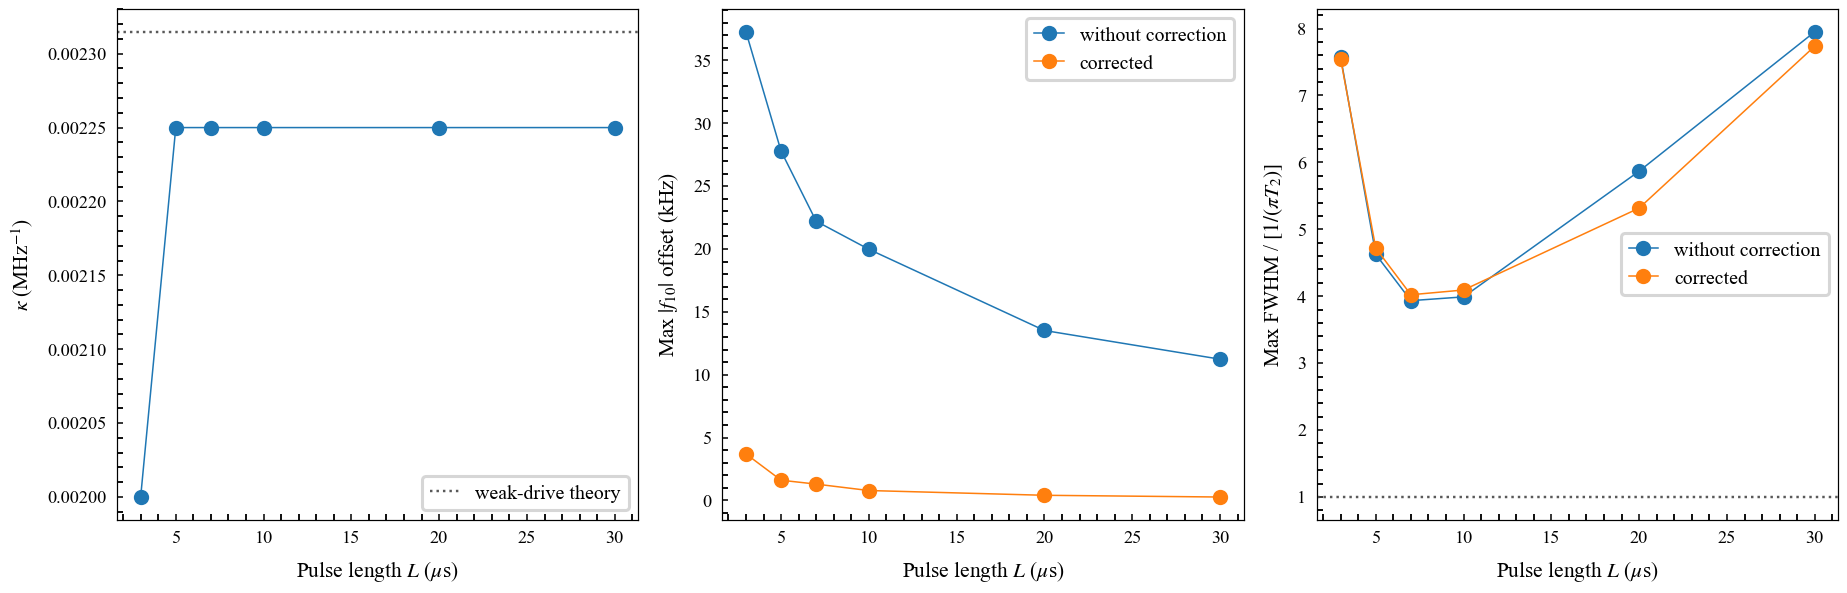

duration_us,kappa_mhz_inv,optimization_center_rms_khz,optimization_max_center_khz,plain_max_center_khz,corrected_max_center_khz,plain_fwhm_t2_min,plain_fwhm_t2_max,corrected_fwhm_t2_min,corrected_fwhm_t2_max,plain_unresolved,corrected_unresolved,plain_max_leakage,corrected_max_leakage,elapsed_s,data_path
3.0,0.002,1.8411711911684832,3.6891980786363012,37.28006558638796,3.699763307336142,7.24268102804821,7.573602740879384,7.278119918165698,7.543873955637783,0,0,0.18834815301489954,0.16593733030152177,65.38438704097643,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/3us/results.npz
5.0,0.00225,0.8183849953704956,1.6022144616477292,27.7885774937958,1.6080805343825493,3.700347335683916,4.625848154508603,3.7003736113529873,4.718118674324691,0,0,0.21598043523813878,0.19238406055619683,97.6149226250127,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/5us/results.npz
7.0,0.00225,0.5533998518377473,1.2924795806032452,22.209926459523412,1.2969929112352314,2.4604499815112133,3.9343197749784893,2.460448602340766,4.02233081850414,0,0,0.1487769486589039,0.11383743802291746,141.29951433395036,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/7us/results.npz
10.0,0.00225,0.32896038039766484,0.7568717707129408,19.9790873816006,0.7869943056196331,2.061771092649703,3.9906542150181417,2.0617544377109267,4.093619307668054,0,0,0.1333264968062126,0.11183382879698966,198.98610866605304,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/10us/results.npz
20.0,0.00225,0.13942834257716377,0.39606638392380006,13.517875412212016,0.40860820804442455,1.0882769527227802,5.869423221847995,1.0878106802336107,5.3178896344621736,0,0,0.09740492299000611,0.0860999010322226,399.06032354198396,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/20us/results.npz
30.0,0.00225,0.11175454638609038,0.2609921142492068,11.235473977473646,0.2704610103352299,0.8637939382255005,7.951793171780619,0.8601830723079671,7.737136267836525,0,0,0.07513954378191338,0.06506934324366118,601.7778192920377,/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/generated/accumulated_phase_duration_sweep/30us/results.npz


In [3]:
display(Image(filename=str(FIGURE_DIR / 'duration_summary.png')))
display(html_table(summary))

## Complete results for every duration

For each pulse length, the notebook shows $\kappa$ optimization, $P_e$ maps, representative 1D detuning sweeps, fitted $f_{10}$ and FWHM, all three populations, leakage, and the complete amplitude-resolved numerical table.

### $L=3~\mu\mathrm{s}$

**Original and accumulated-phase-corrected pulse**

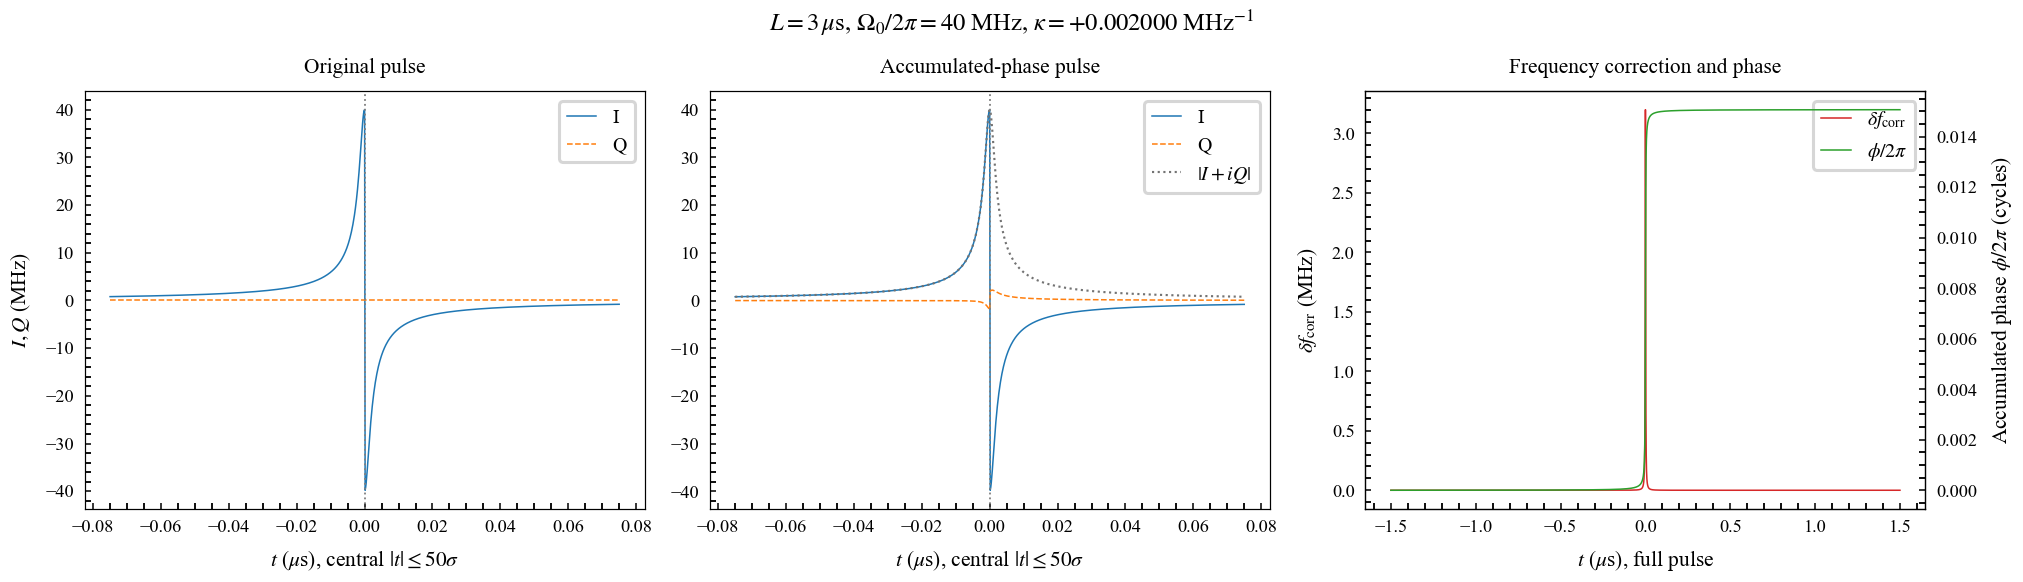

**Quadratic phase-coefficient optimization**

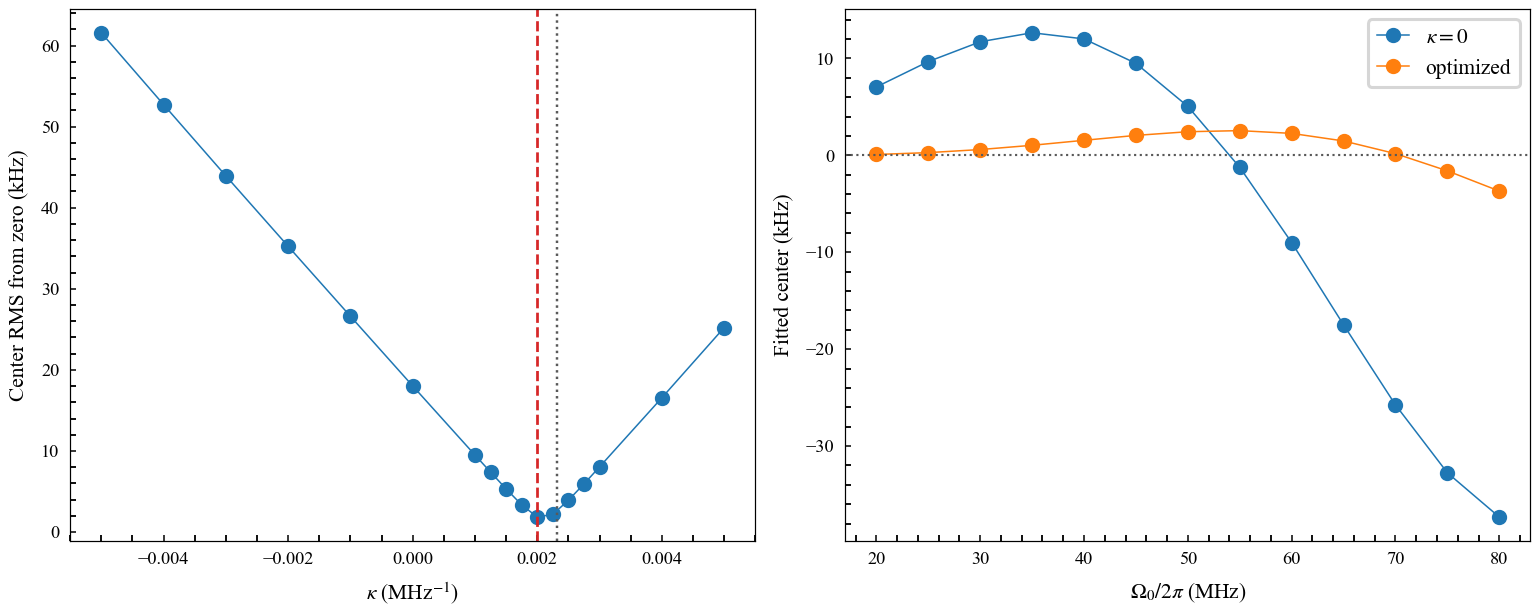

**Excited-state maps with T2-limit bounds**

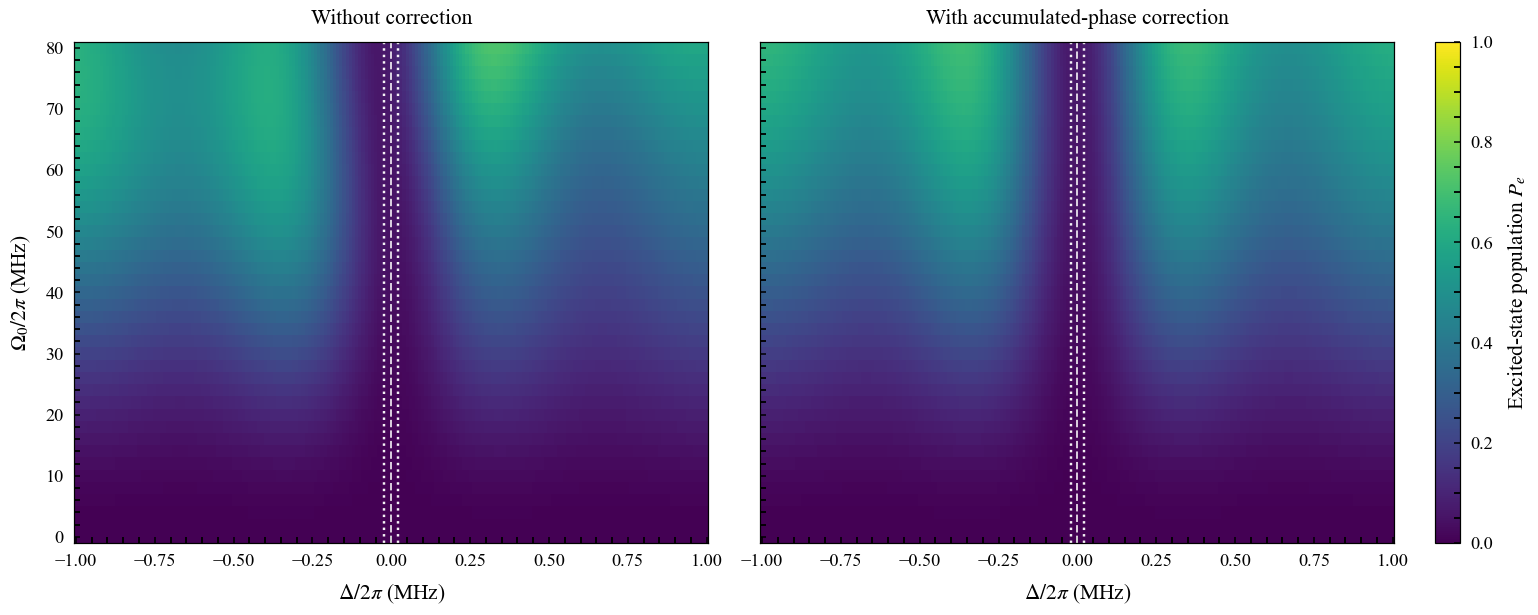

**One-dimensional detuning sweeps**

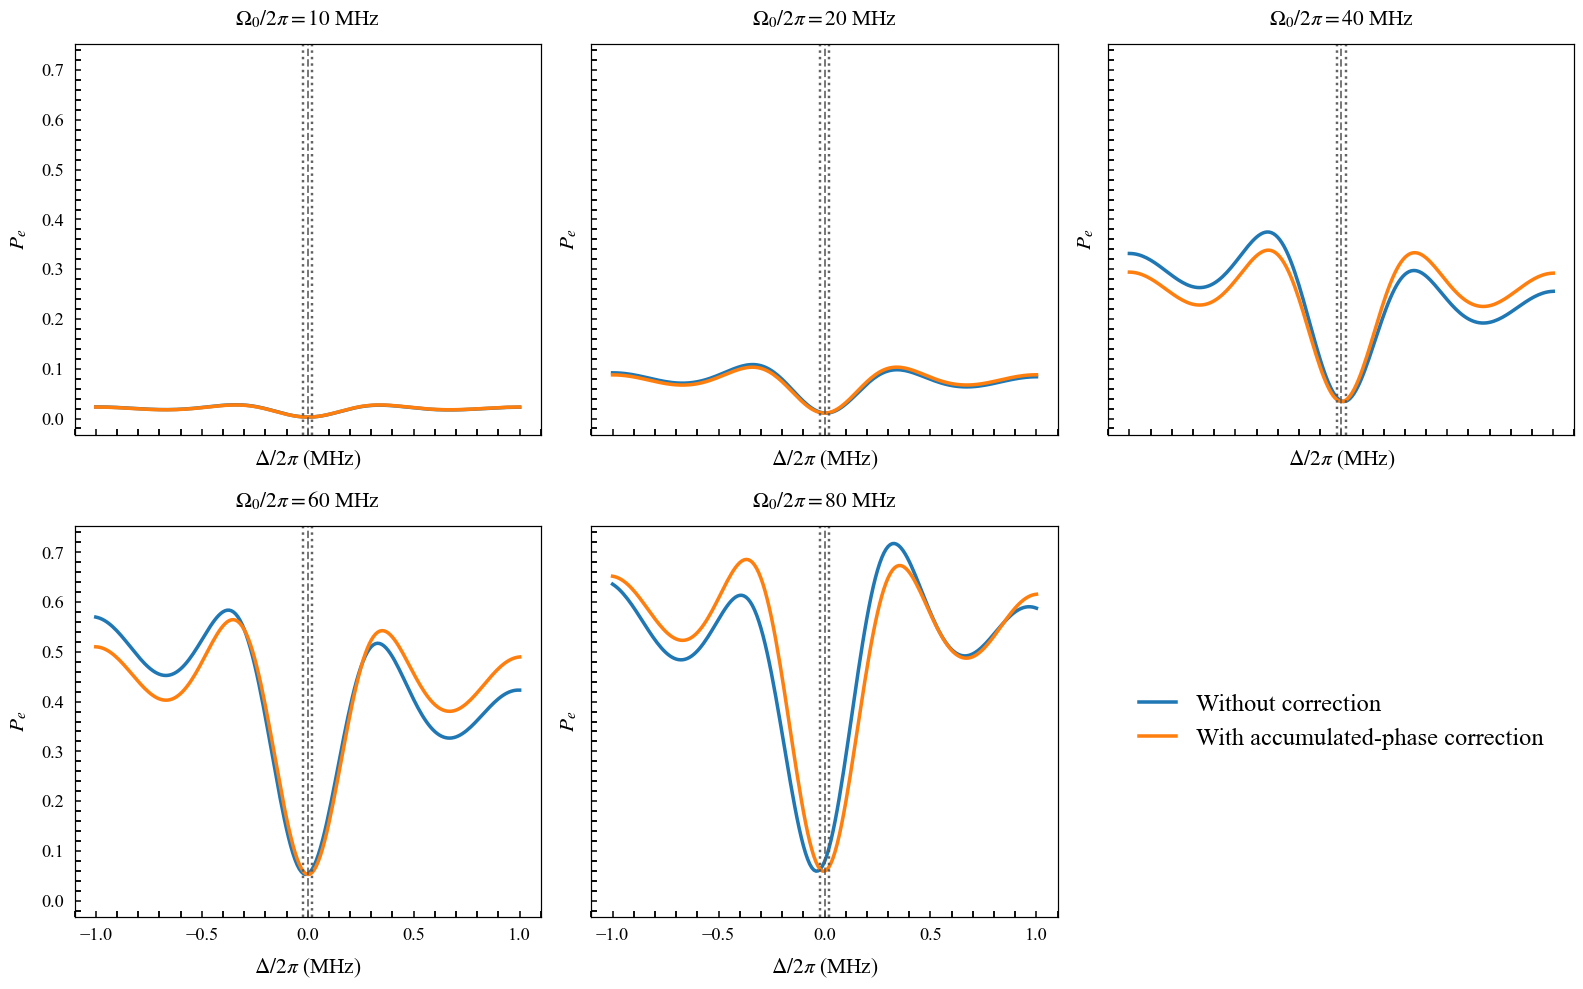

**Fitted f10 offsets and FWHM in T2 units**

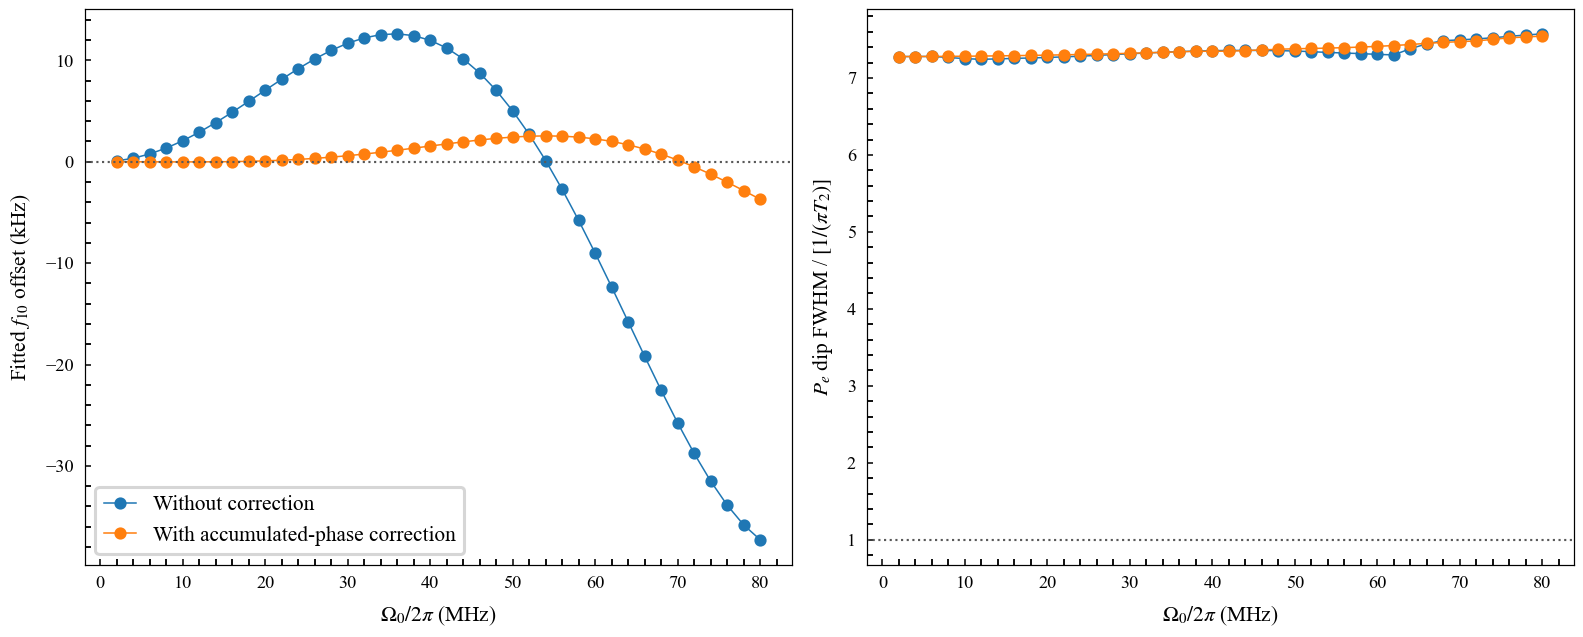

**Complete Pg, Pe, and Pf maps**

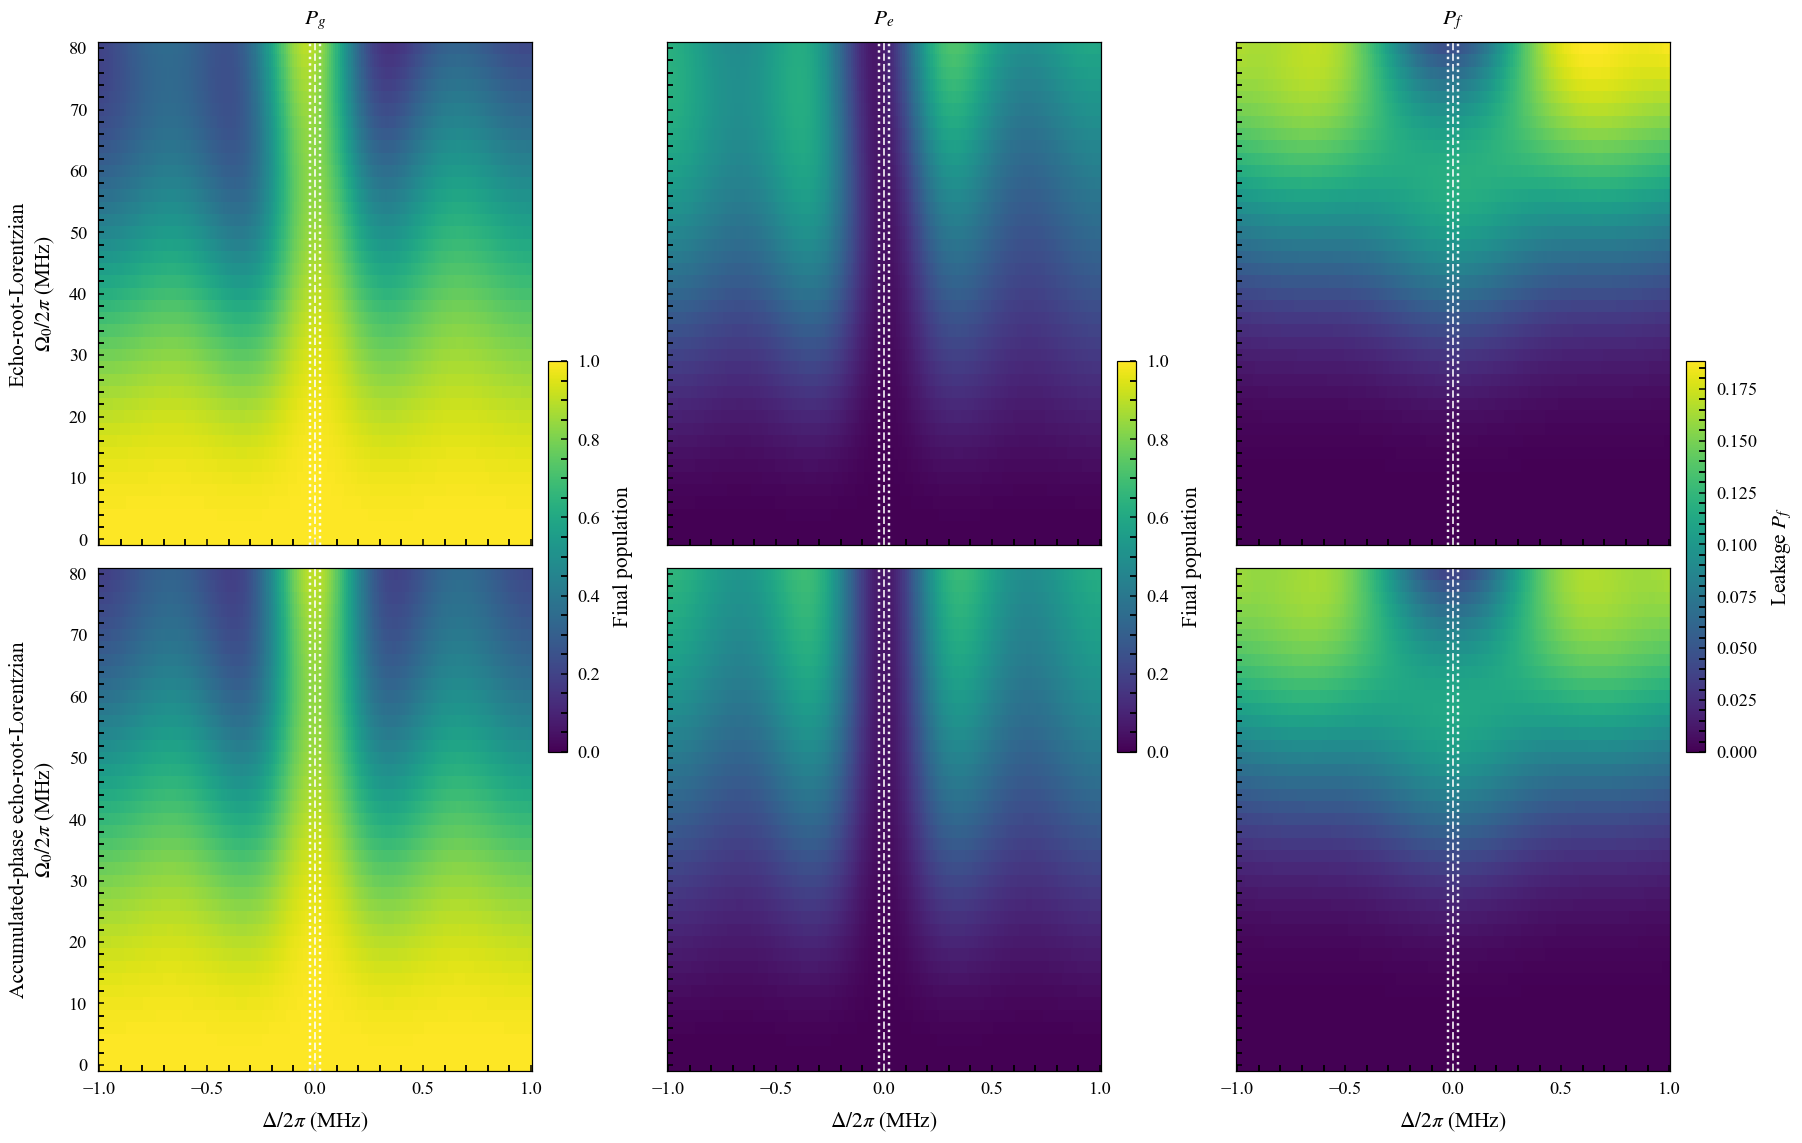

**Leakage difference and worst-case leakage**

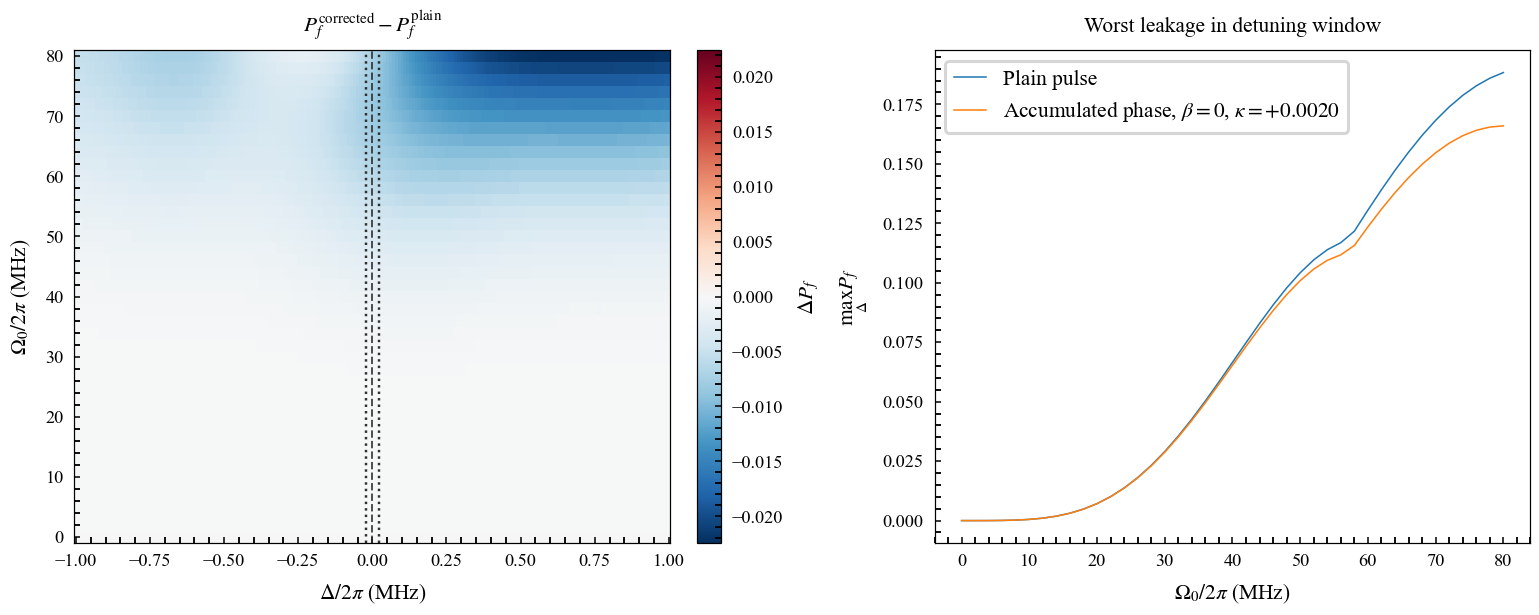

duration_us,rabi_mhz,plain_center_khz,corrected_center_khz,plain_fwhm_mhz,corrected_fwhm_mhz,plain_fwhm_t2,corrected_fwhm_t2,plain_max_leakage,corrected_max_leakage
3.0,2.0,0.0869766880798324,-0.0011973532230064312,0.3169223674631295,0.31692168574326995,7.278135573891109,7.278119918165698,8.441997953772757e-07,8.441656671124777e-07
3.0,4.0,0.34581328304637665,-0.00450079947883645,0.3169506070260952,0.3169466104190526,7.278784096649085,7.278692314399304,1.34396784792997e-05,1.343750319672229e-05
3.0,6.0,0.7702608113327373,-0.009056954407554465,0.3170017028057961,0.31698808107990806,7.279957513391152,7.279644689879966,6.747185006667703e-05,6.744724094722512e-05
3.0,8.0,1.3500082149074133,-0.013484696458271423,0.3164125020485594,0.31704600102079206,7.266426493079351,7.280974823772249,0.00021075854988940006,0.00021062159795910446
3.0,10.0,2.070835301226978,-0.015935786839591924,0.31574155298082385,0.31712025211438444,7.251018119359173,7.282680003277251,0.000506831021778249,0.0005063149996067441
3.0,12.0,2.914821740075161,-0.014177449680490839,0.31537851897449054,0.3172107103890004,7.24268102804821,7.284757381379988,0.0010316803967966995,0.0010301626889887565
3.0,14.0,3.8606083693802318,-0.005694689503163524,0.31560934371790883,0.31731726369514573,7.247981928044177,7.28720438256258,0.0018697971456281555,0.0018660380512645312
3.0,16.0,4.883707651552901,0.012190432790753247,0.3158938314478753,0.3174398297746628,7.254515200796045,7.290019117762958,0.003109659599710011,0.003101455725708808
3.0,18.0,5.959747845711967,0.04218585738941816,0.3161334090546637,0.3175783727942131,7.260017110669533,7.293200764066986,0.004838850752044573,0.004822607477772516
3.0,20.0,7.0556917858392705,0.08688668112391193,0.31641372291860026,0.317732916258135,7.266454530411479,7.296749861252793,0.007138999331863779,0.007109234955896511


### $L=5~\mu\mathrm{s}$

**Original and accumulated-phase-corrected pulse**

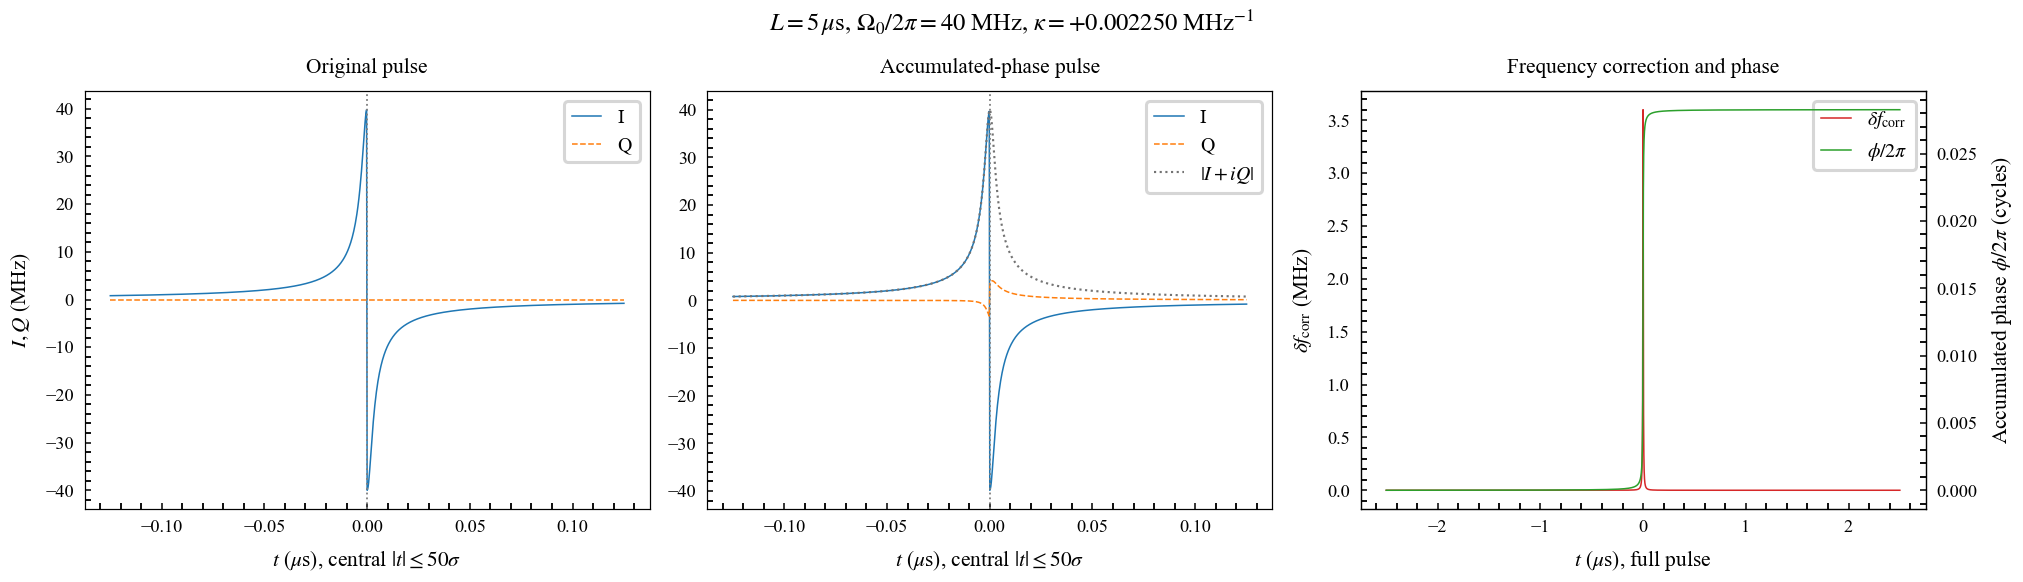

**Quadratic phase-coefficient optimization**

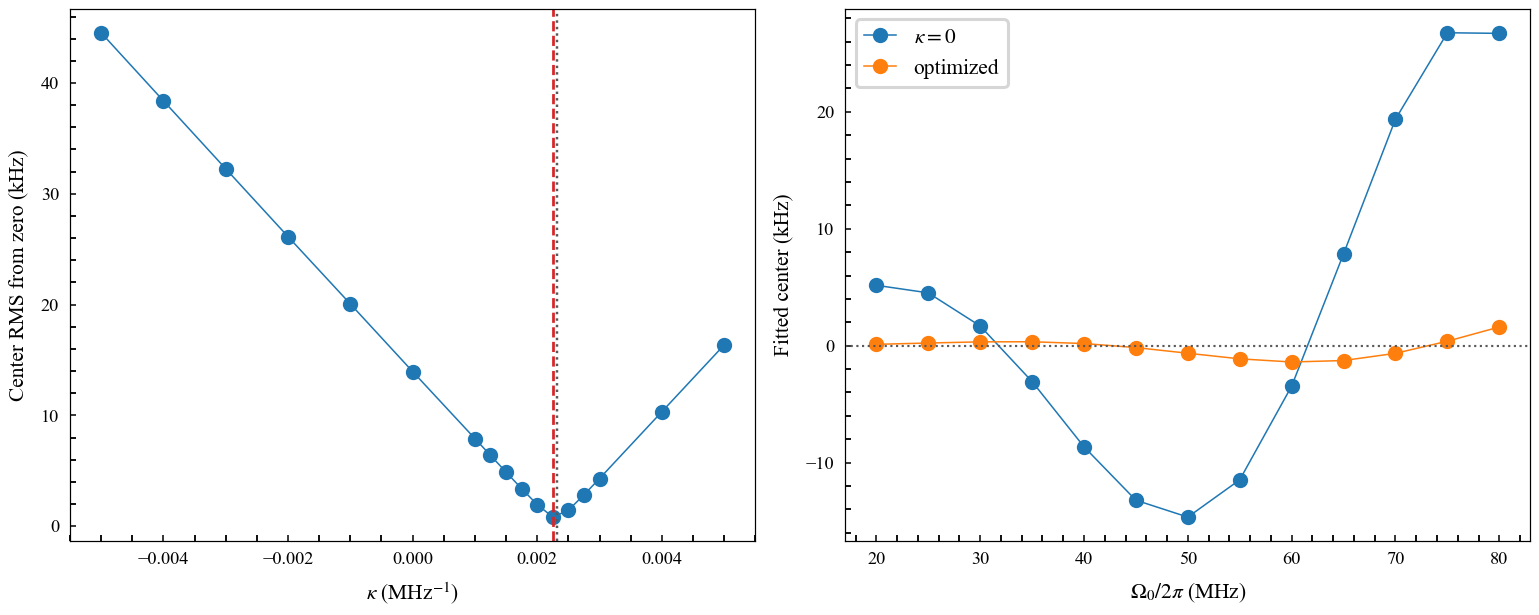

**Excited-state maps with T2-limit bounds**

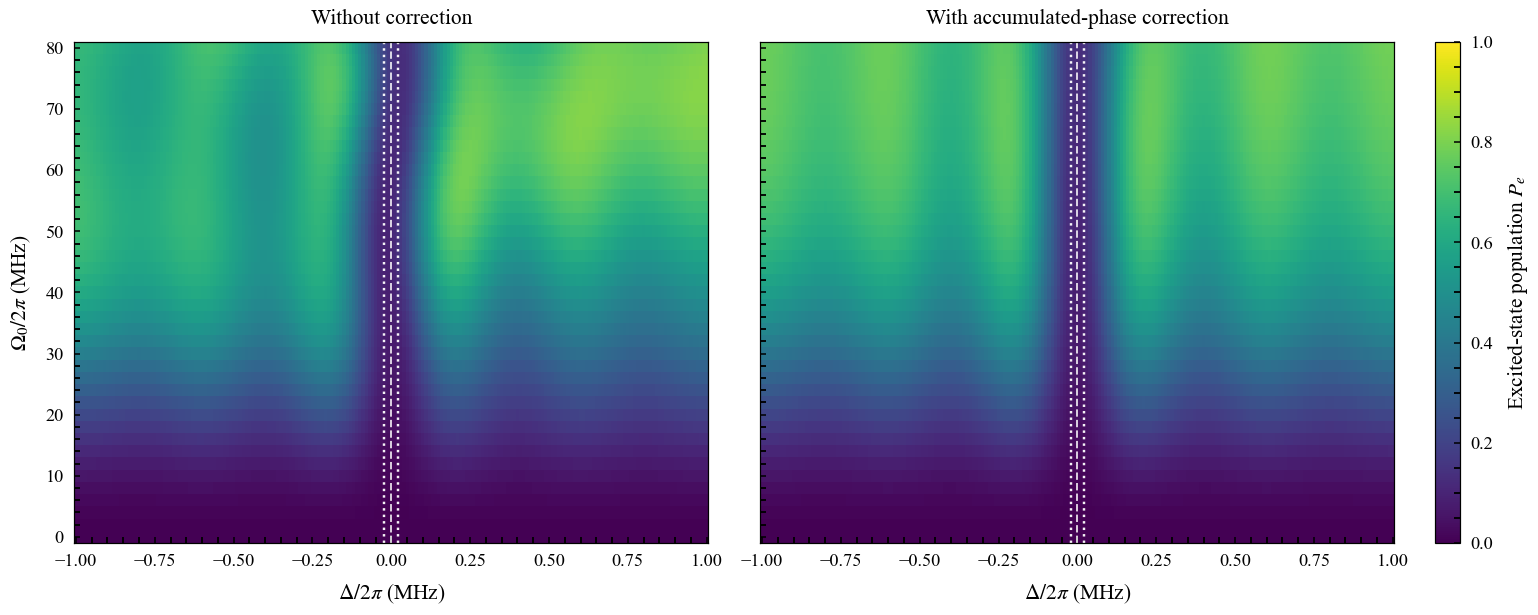

**One-dimensional detuning sweeps**

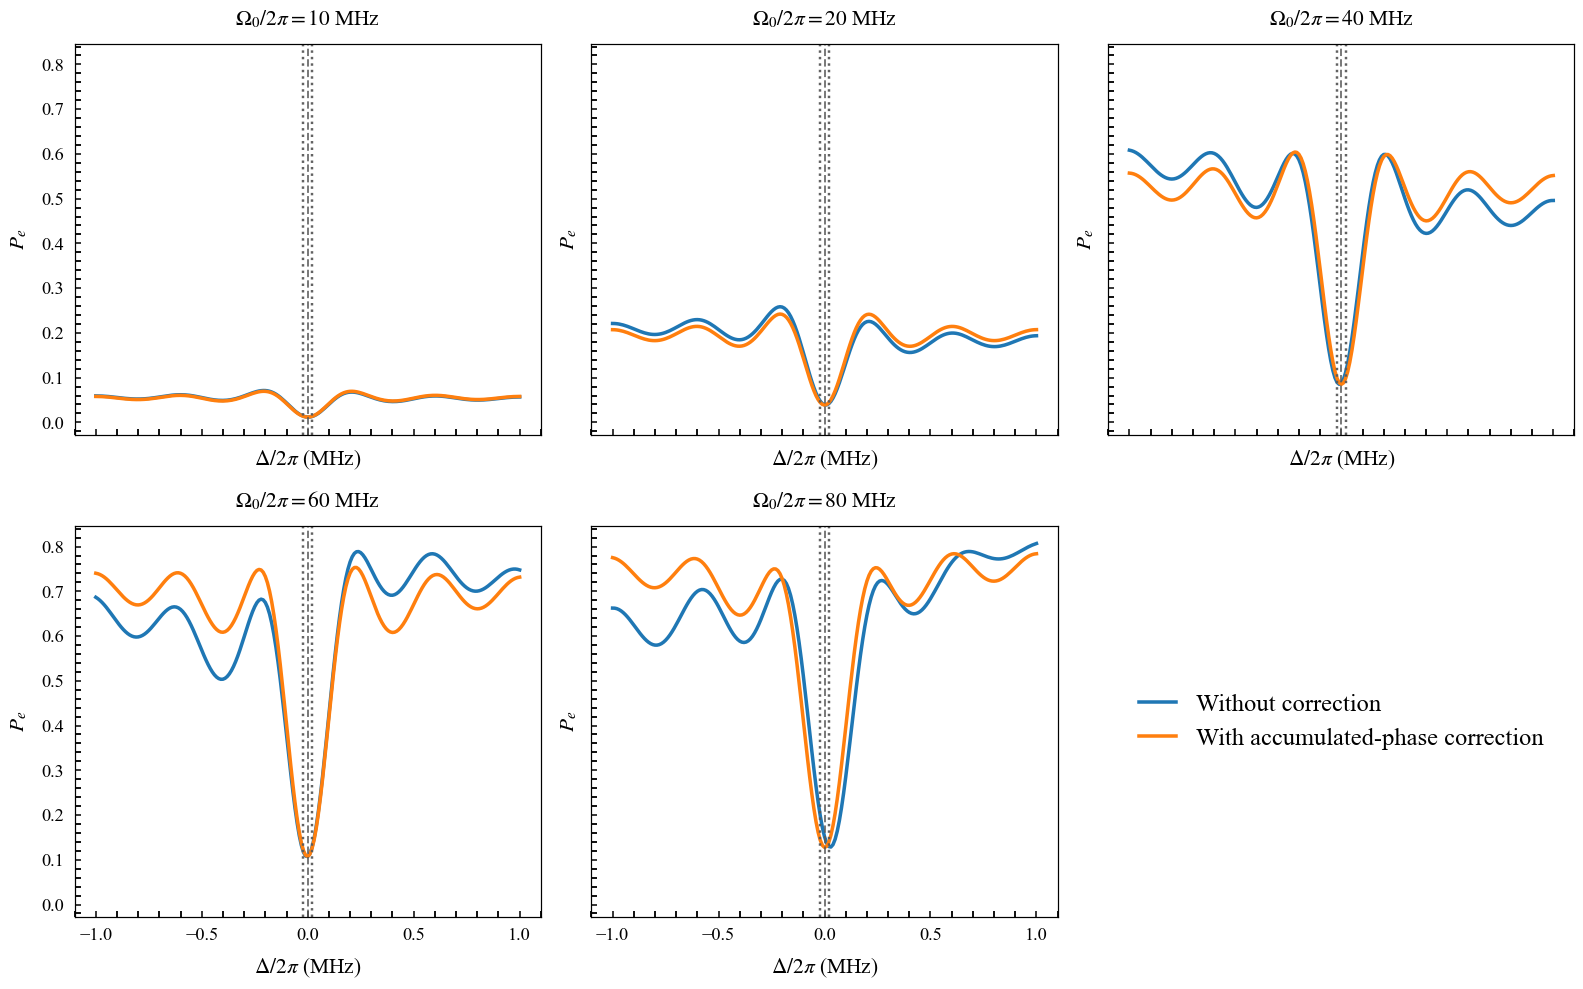

**Fitted f10 offsets and FWHM in T2 units**

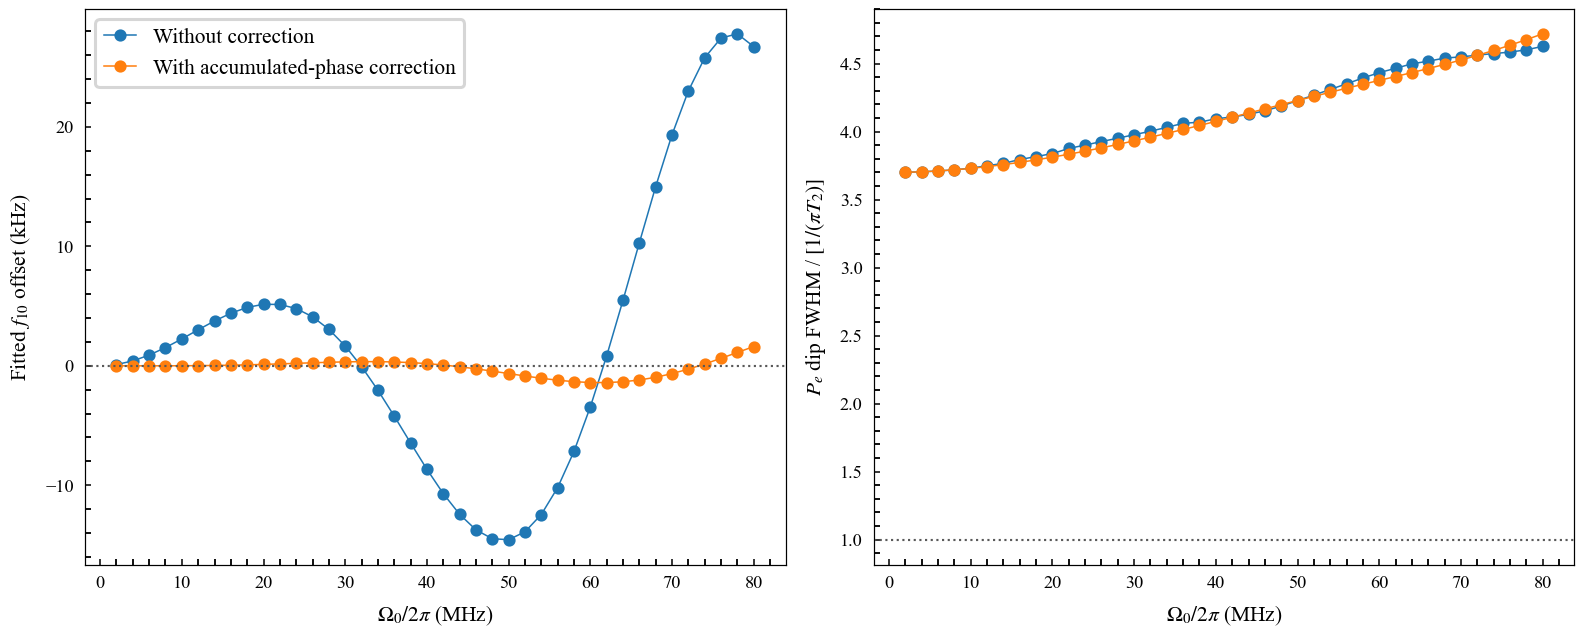

**Complete Pg, Pe, and Pf maps**

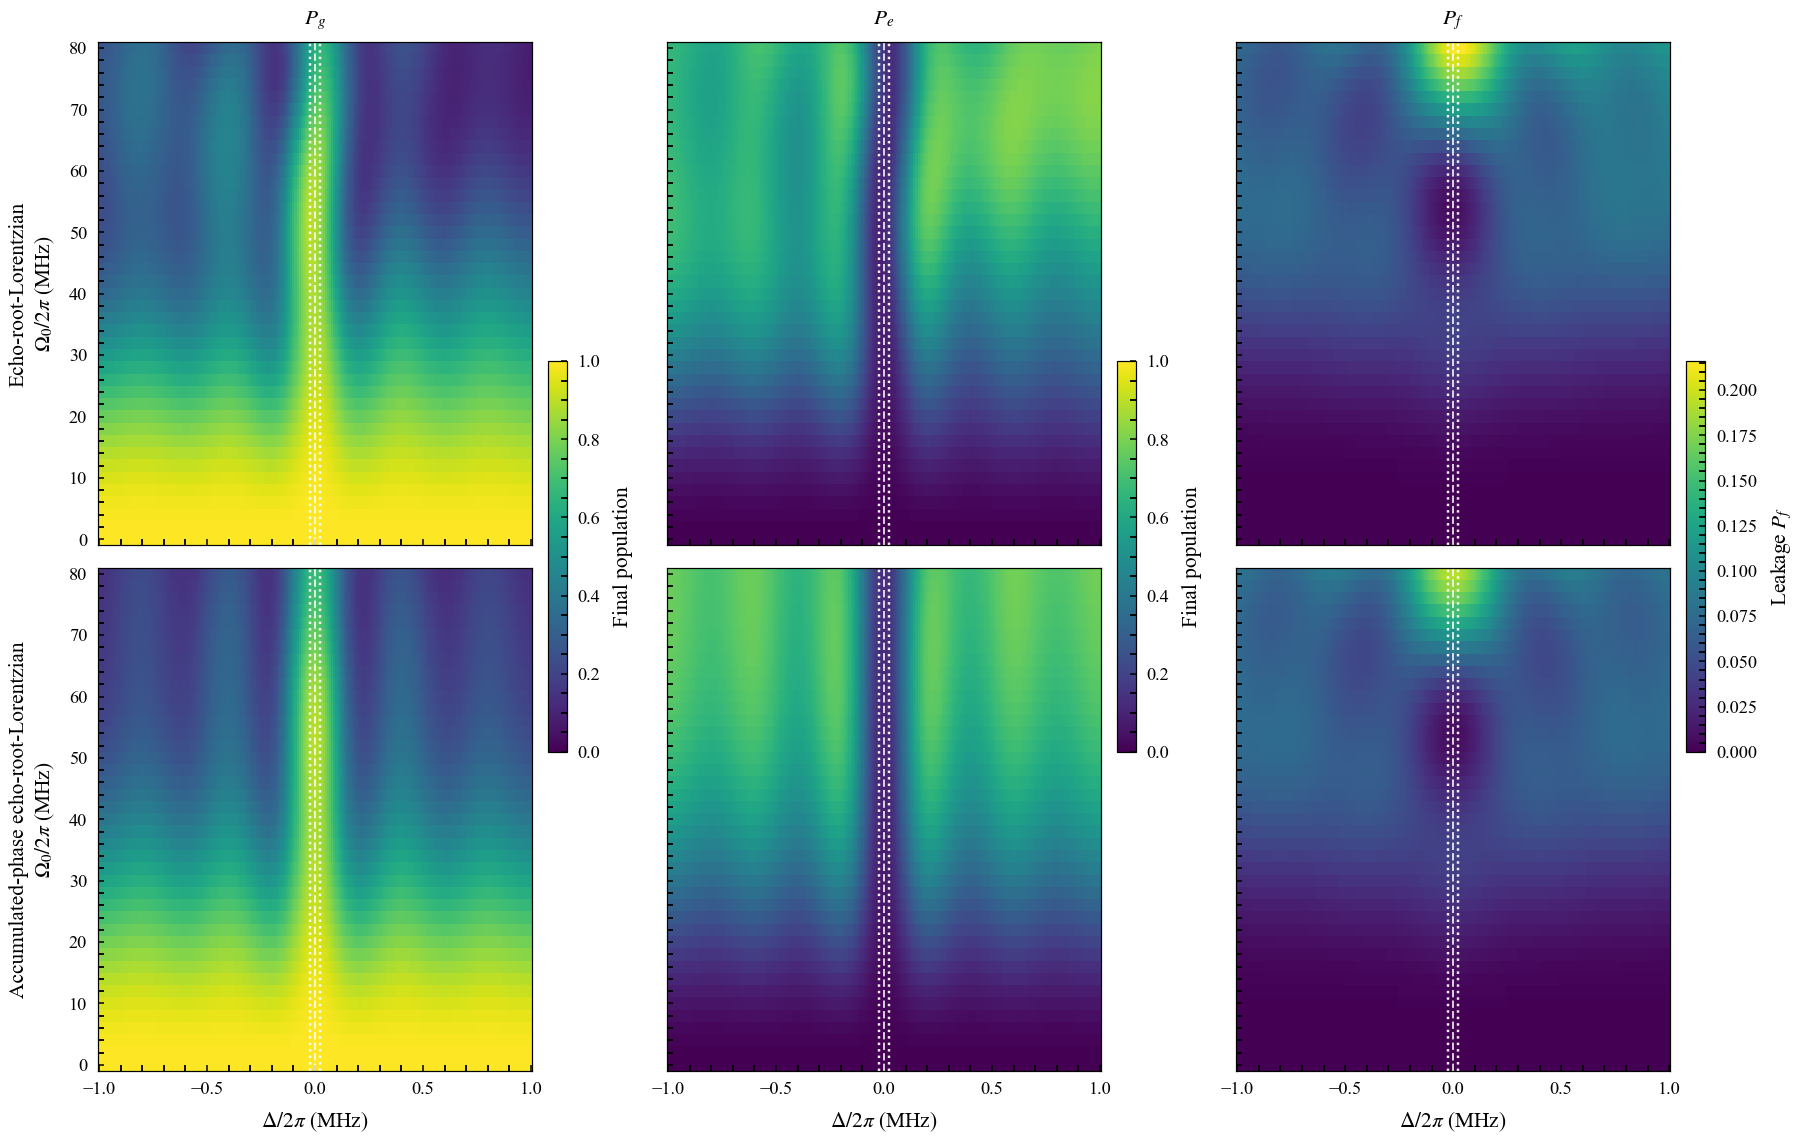

**Leakage difference and worst-case leakage**

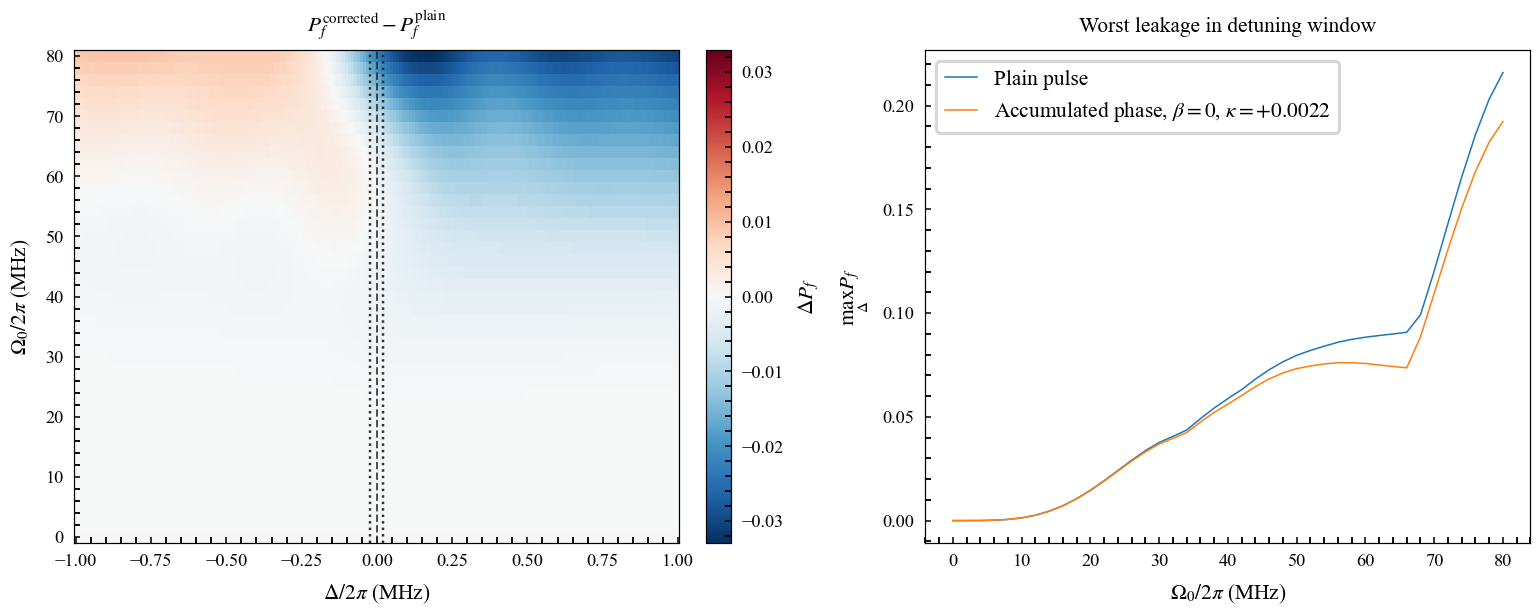

duration_us,rabi_mhz,plain_center_khz,corrected_center_khz,plain_fwhm_mhz,corrected_fwhm_mhz,plain_fwhm_t2,corrected_fwhm_t2,plain_max_leakage,corrected_max_leakage
5.0,2.0,0.10455550440566945,-0.0003201095284540704,0.1611295676145062,0.16113071177390859,3.700347335683916,3.7003736113529873,2.3657753626386388e-06,2.365585328441081e-06
5.0,4.0,0.4107113504750196,-0.0010076731897388095,0.1612896169242159,0.16129114684149476,3.7040228748511232,3.7040580094661446,3.732844005547029e-05,3.731643654072237e-05
5.0,6.0,0.8962970449139868,-0.001276819024052629,0.16155230019371714,0.16155627117927165,3.7100554072461285,3.710146601097352,0.00018462136350817277,0.0001844876045916716
5.0,8.0,1.5255473772774586,7.665204819123525e-05,0.16192847389276838,0.16192286476521323,3.718694252156138,3.7185654383045805,0.000564668523962658,0.0005639398223014515
5.0,10.0,2.250819141085838,0.0045254249797377685,0.16243158047436226,0.16238674845447518,3.7302481160827137,3.7292185468497134,0.0013212852889764792,0.001318614301236224
5.0,12.0,3.014890111230532,0.01361739184237337,0.16324473180788185,0.16294304292768189,3.748922170851456,3.7419938729569053,0.002600120507019129,0.0025925275838290605
5.0,14.0,3.7537687853347954,0.02875417125065684,0.16398460145718607,0.16358642027087814,3.7659133086425425,3.756769060856816,0.00452519694258712,0.004507140767836004
5.0,16.0,4.3999467385587,0.050959400589055556,0.16522274094890924,0.16431001882779556,3.794347234440469,3.773386532323009,0.007176176465688051,0.00713860355346042
5.0,18.0,4.886019149163114,0.08065653400550211,0.16615945077225452,0.16511007105973918,3.815858815154303,3.7917597656699966,0.010568992777476494,0.010498572611707922
5.0,20.0,5.150169007833889,0.11747655914487683,0.1671346759475798,0.16598022132243778,3.8382549025554704,3.811742803258261,0.014642251884058079,0.014521031396819258


### $L=7~\mu\mathrm{s}$

**Original and accumulated-phase-corrected pulse**

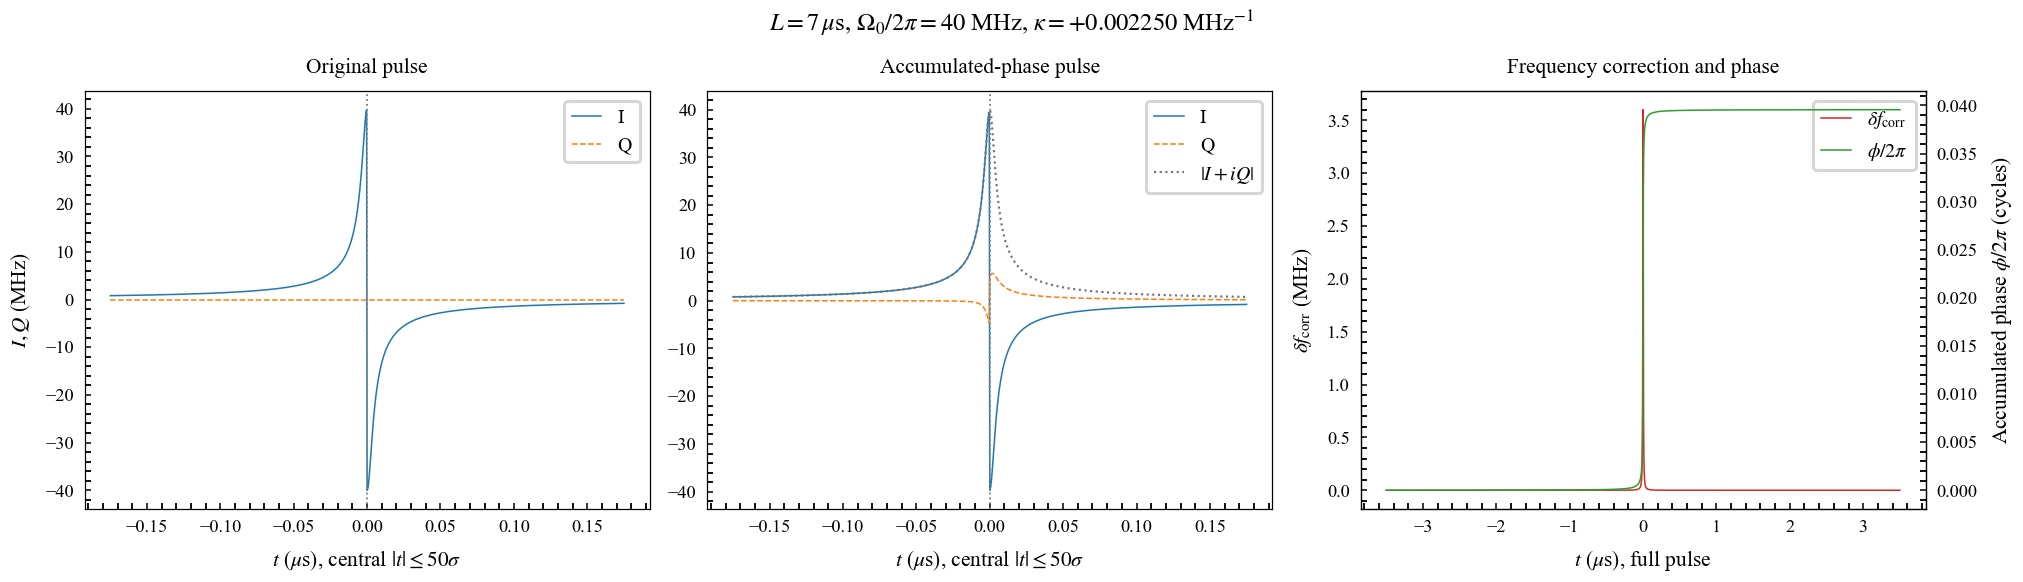

**Quadratic phase-coefficient optimization**

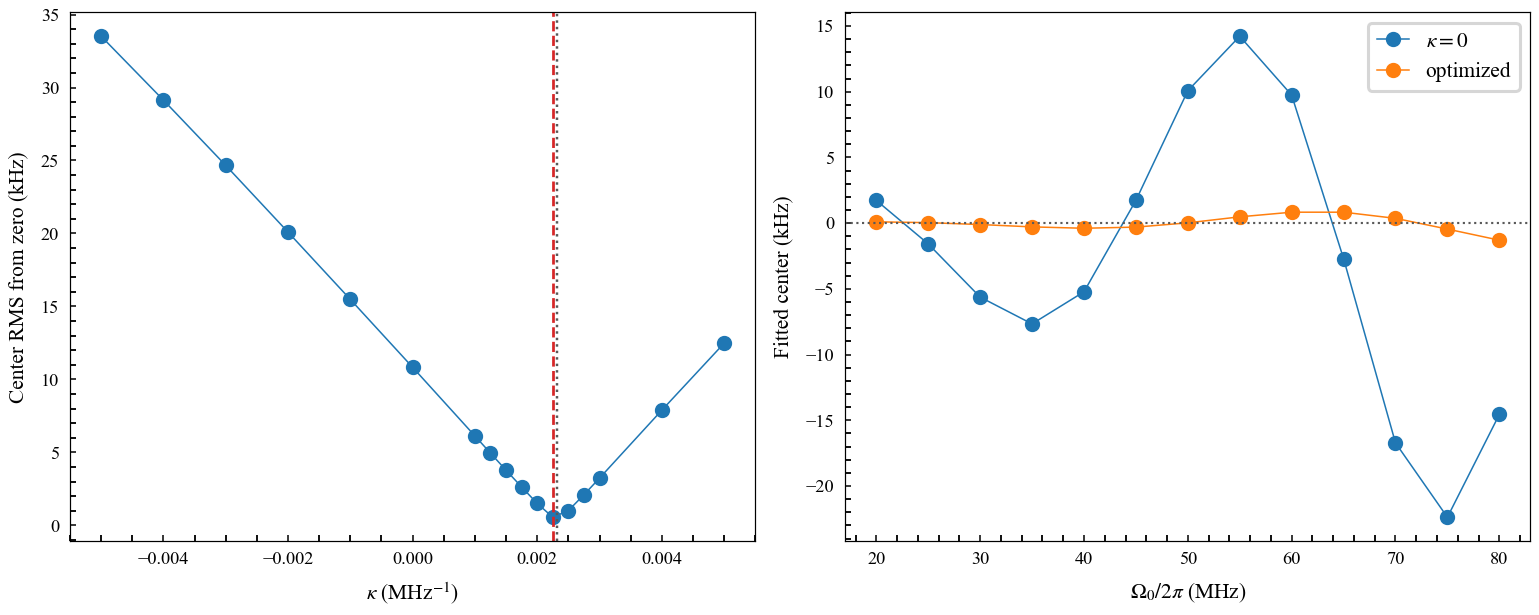

**Excited-state maps with T2-limit bounds**

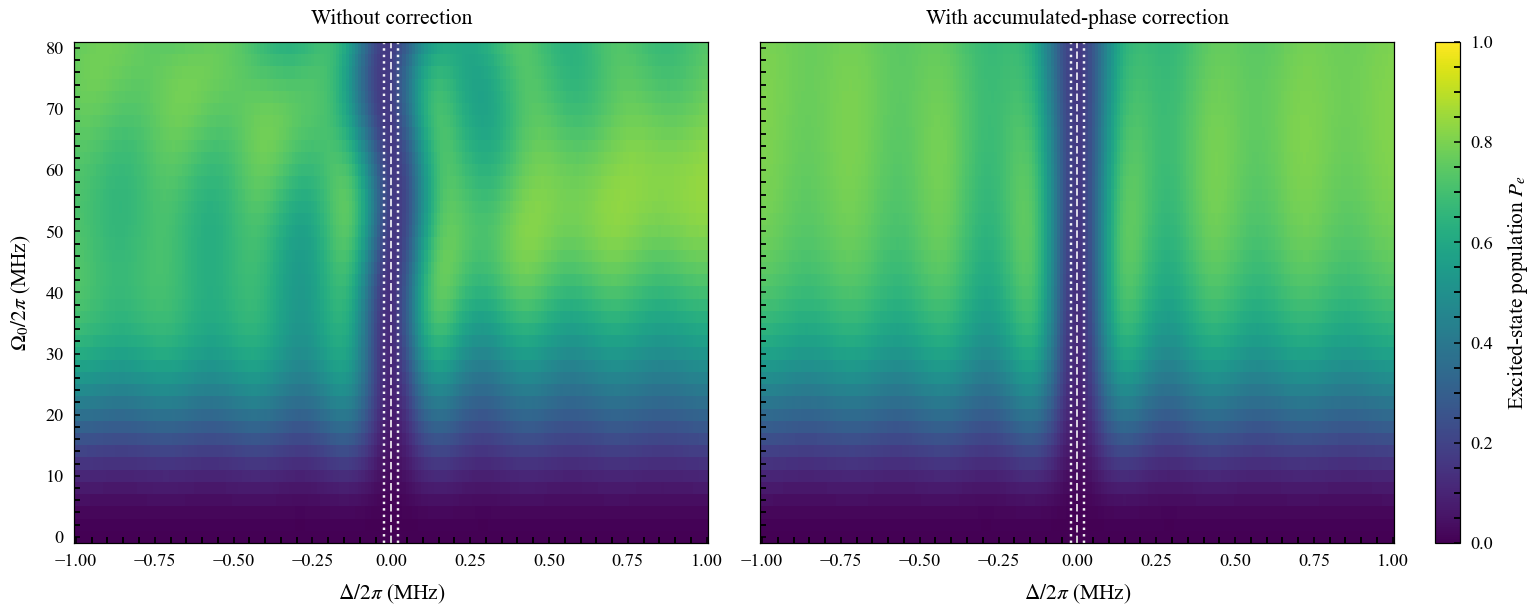

**One-dimensional detuning sweeps**

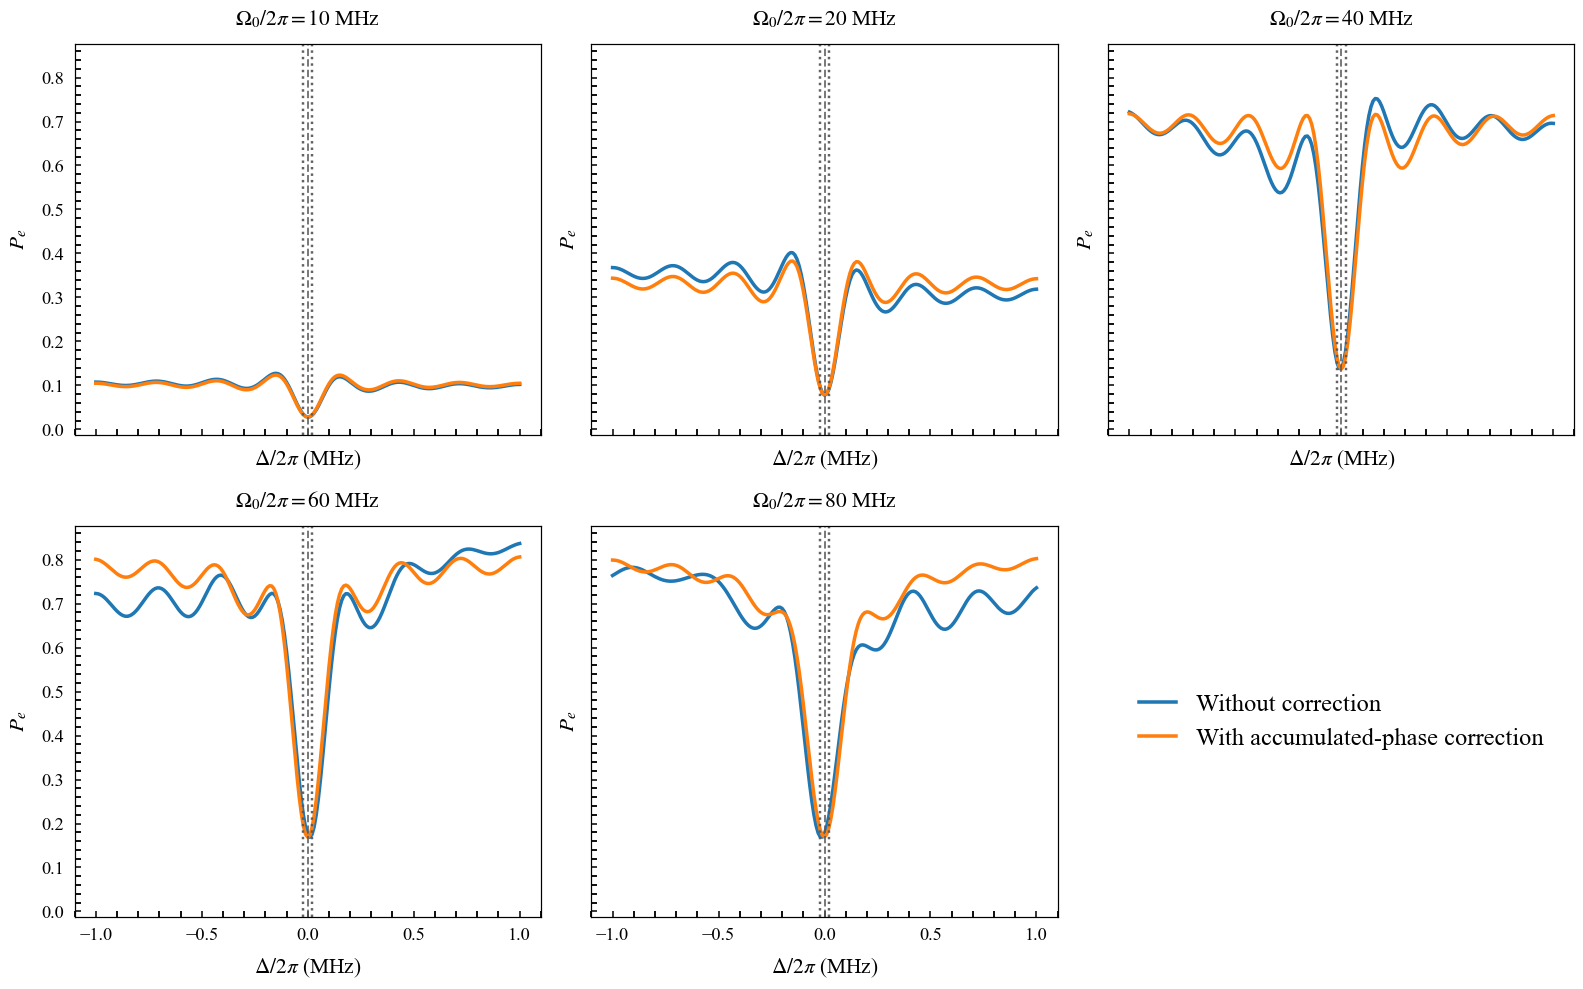

**Fitted f10 offsets and FWHM in T2 units**

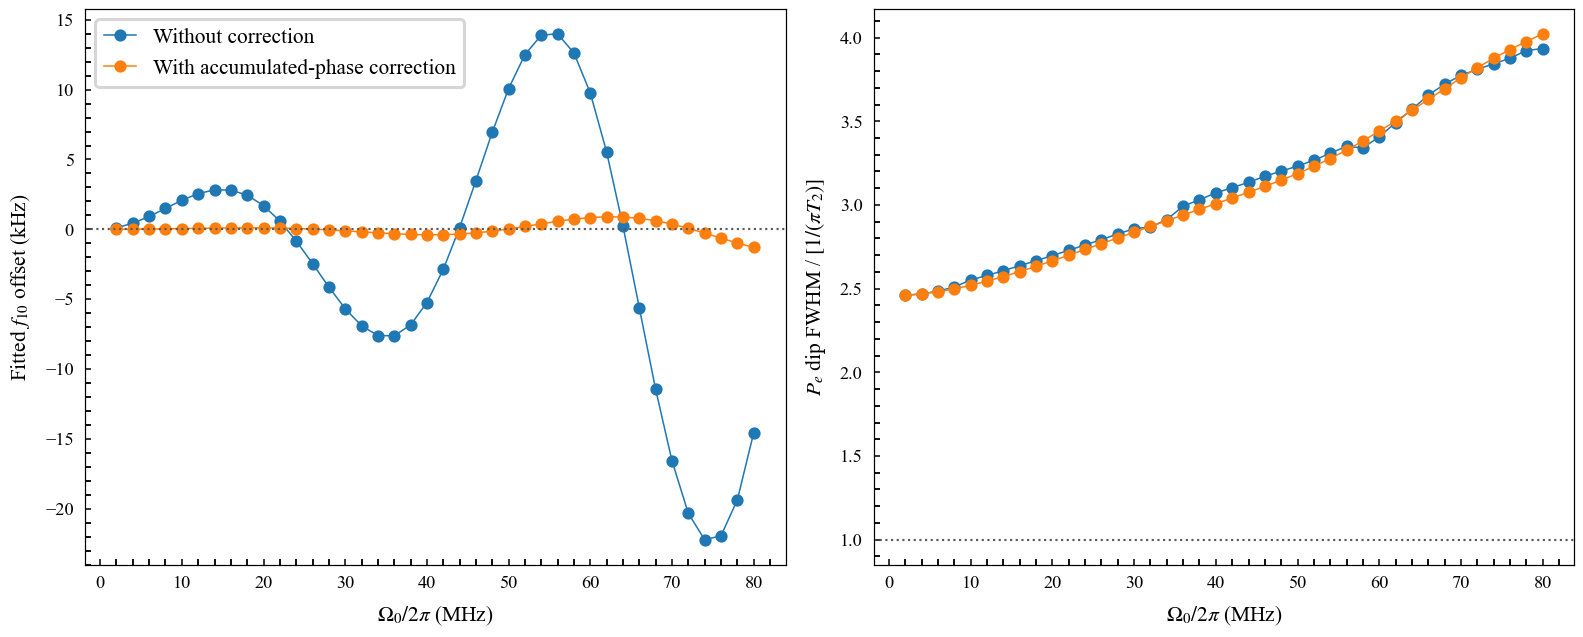

**Complete Pg, Pe, and Pf maps**

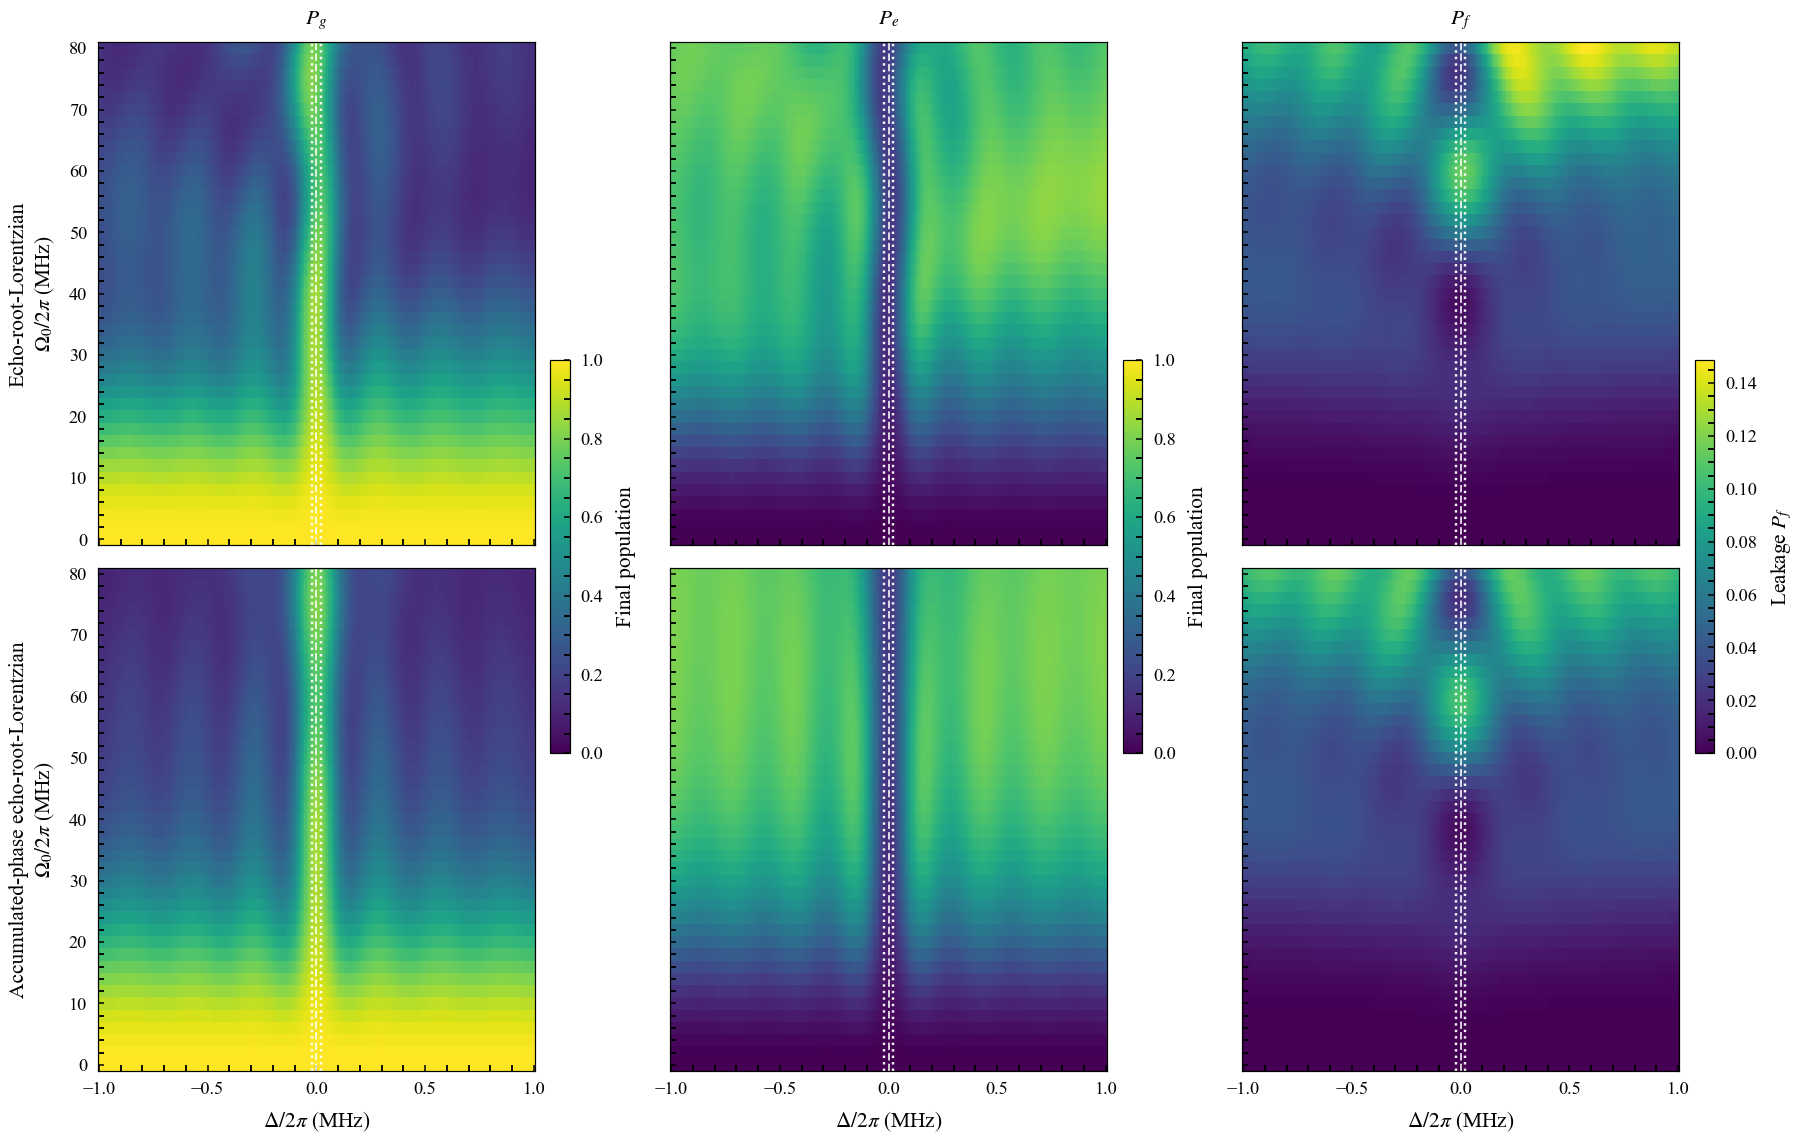

**Leakage difference and worst-case leakage**

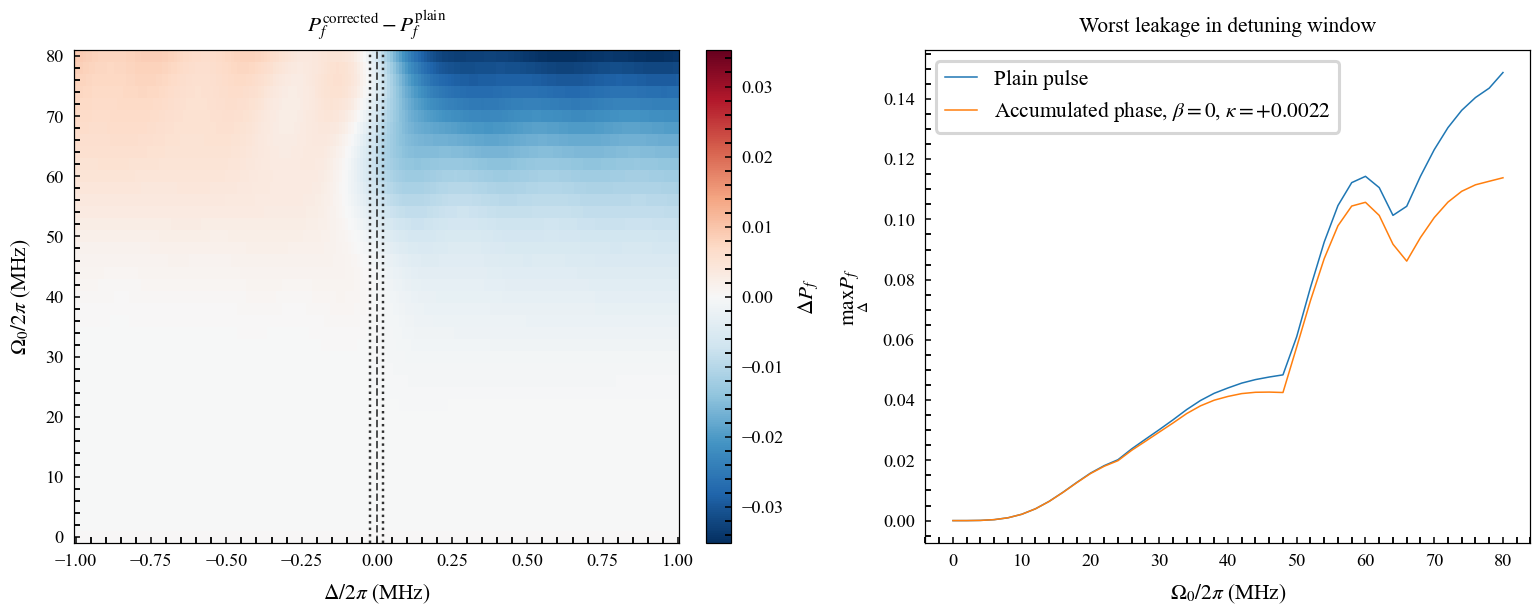

duration_us,rabi_mhz,plain_center_khz,corrected_center_khz,plain_fwhm_mhz,corrected_fwhm_mhz,plain_fwhm_t2,corrected_fwhm_t2,plain_max_leakage,corrected_max_leakage
7.0,2.0,0.11323523146204571,0.0024938435847401746,0.10713892661774886,0.10713886656253846,2.4604499815112133,2.460448602340766,4.190858816236494e-06,4.190473305287198e-06
7.0,4.0,0.43679867290589225,0.00981164893986659,0.10748881904293717,0.10748348599907989,2.468485275855322,2.468362802277564,6.525931207291679e-05,6.523528756461473e-05
7.0,6.0,0.923872038306972,0.021452603953578665,0.10821578807695348,0.10804407906343039,2.4851801504706548,2.4812368457121936,0.0003156775485986768,0.0003154158415620442
7.0,8.0,1.501621721904817,0.03655344738178509,0.10929808028169873,0.10880161371772532,2.5100350367311455,2.4986336610900817,0.0009355147672465428,0.0009341342021453958
7.0,10.0,2.078479842641108,0.053857626719224165,0.11112907291317911,0.10973237980742506,2.552083859959945,2.5200087437093397,0.002100215571903738,0.0020953642612393385
7.0,12.0,2.553476937564678,0.07169477733309693,0.11228971793898121,0.11081027274280075,2.5787381220701535,2.544762600562679,0.0039235535966012074,0.003910471903152327
7.0,14.0,2.827002231744063,0.08799001111435124,0.11354114580354707,0.11200900263731317,2.6074772159124806,2.5722914832937236,0.006408263453251617,0.006379091396926031
7.0,16.0,2.8122762377364197,0.10032362427190573,0.11482829265937153,0.11330395279362884,2.637036597899894,2.60203006840698,0.009416015561355668,0.009359802346042011
7.0,18.0,2.4466316973495434,0.10605968538329723,0.11614312092914314,0.11467352084751871,2.6672316847294653,2.633482256694196,0.012665317169907084,0.01256911351140739
7.0,20.0,1.7014959413597788,0.10255586122285154,0.11747195691639489,0.11609987925771861,2.6977484593834626,2.666238637916176,0.015761068598064254,0.015612237088790983


### $L=10~\mu\mathrm{s}$

**Original and accumulated-phase-corrected pulse**

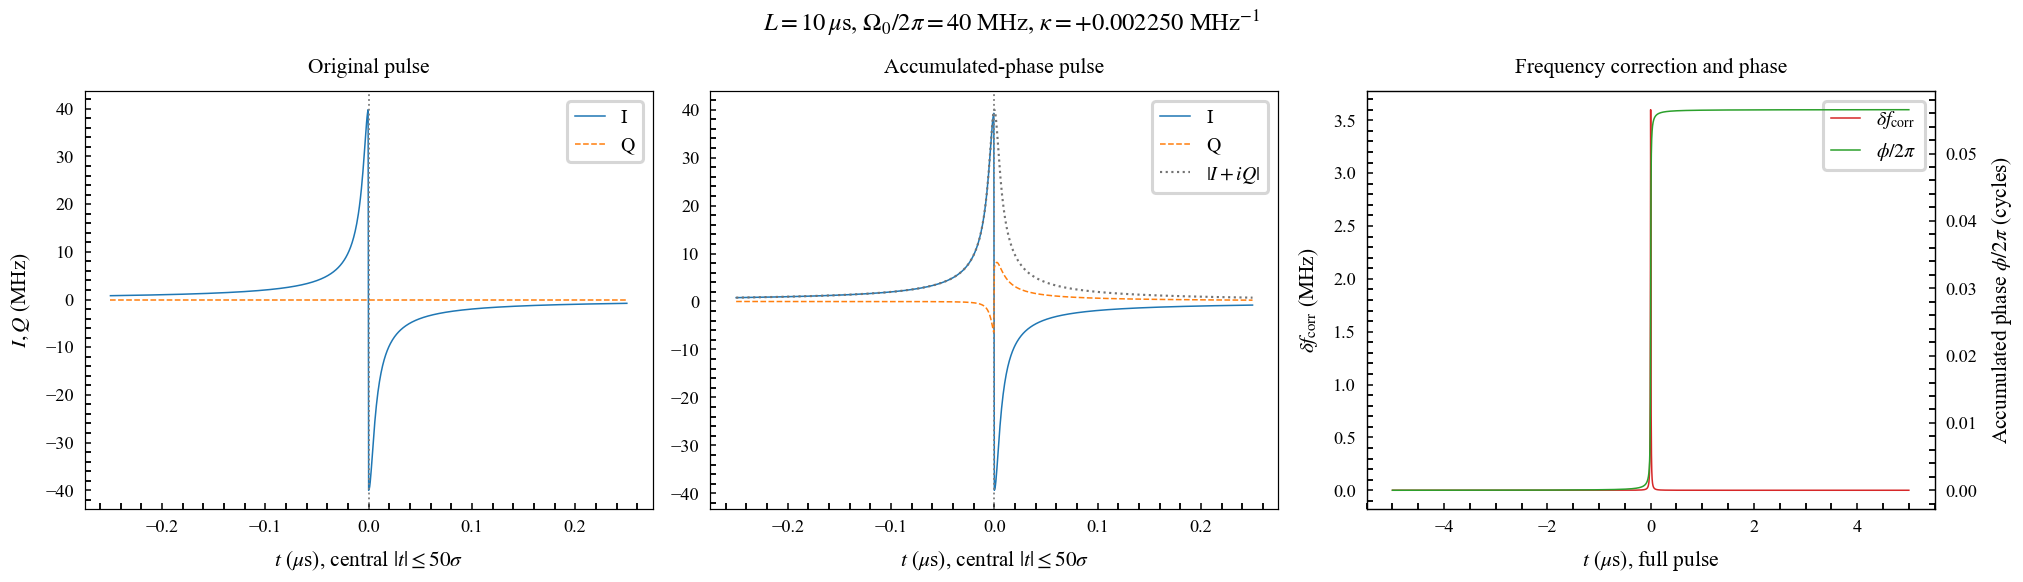

**Quadratic phase-coefficient optimization**

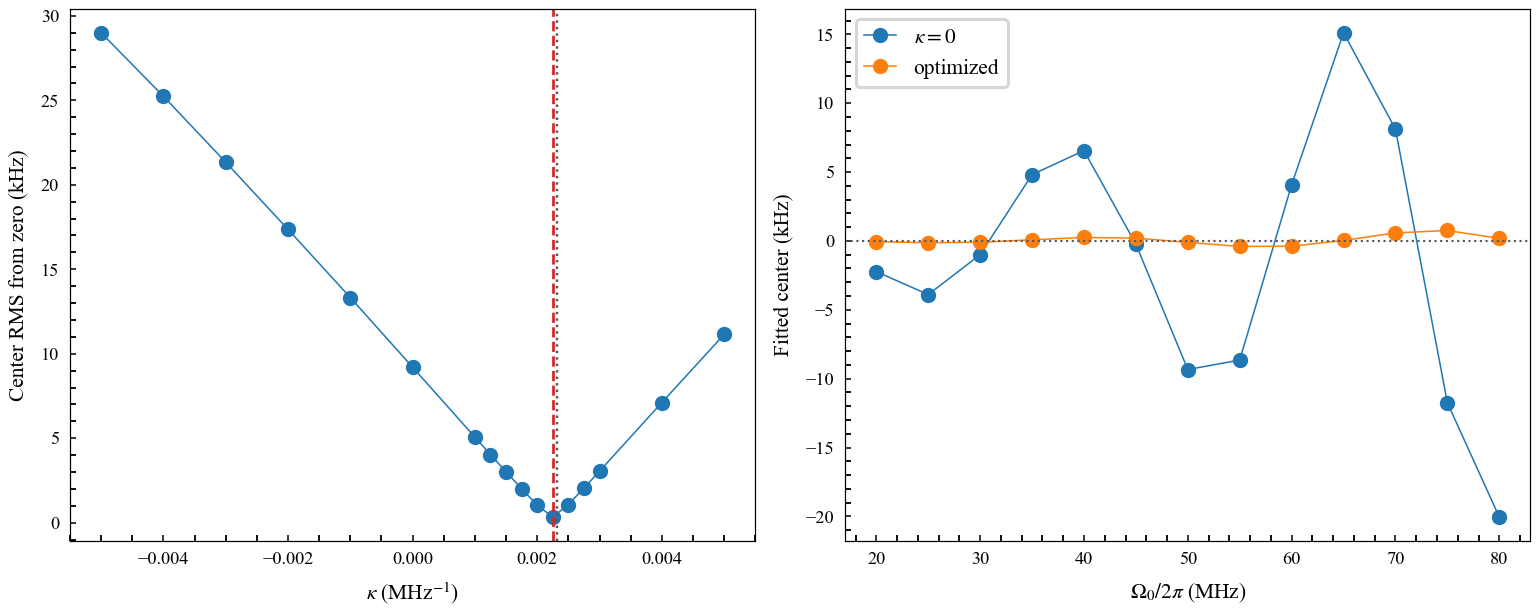

**Excited-state maps with T2-limit bounds**

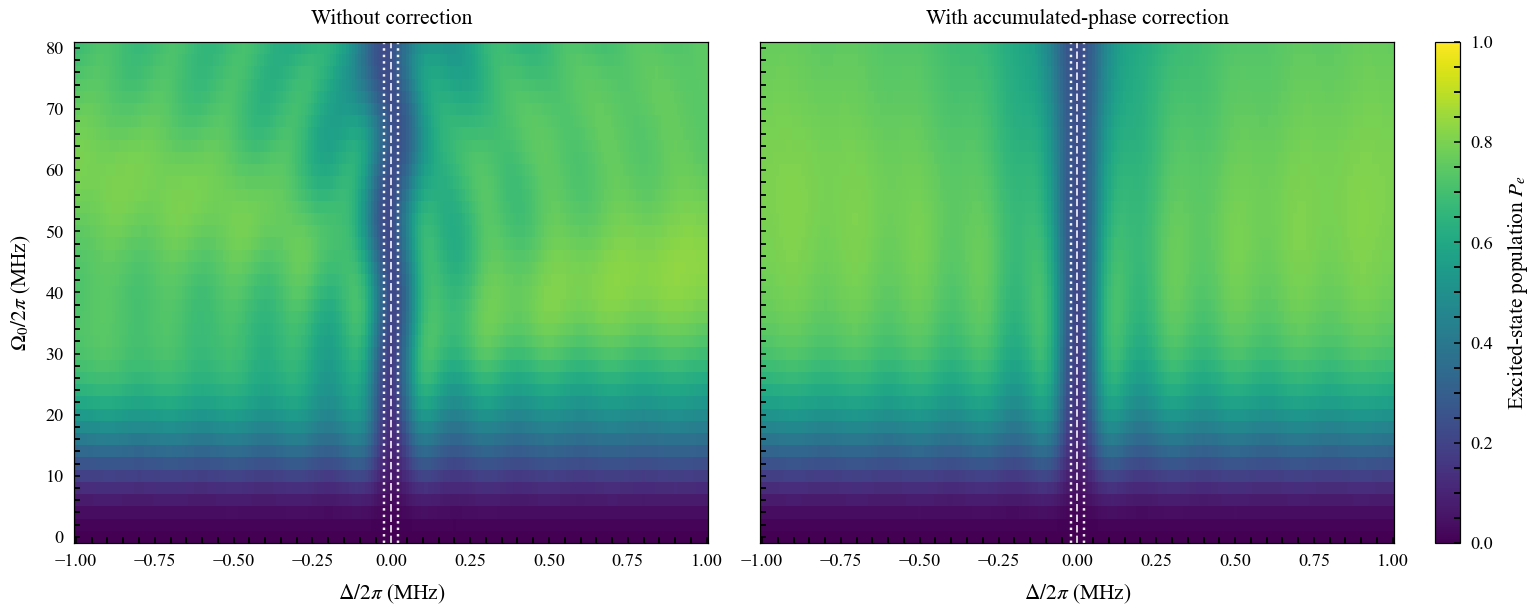

**One-dimensional detuning sweeps**

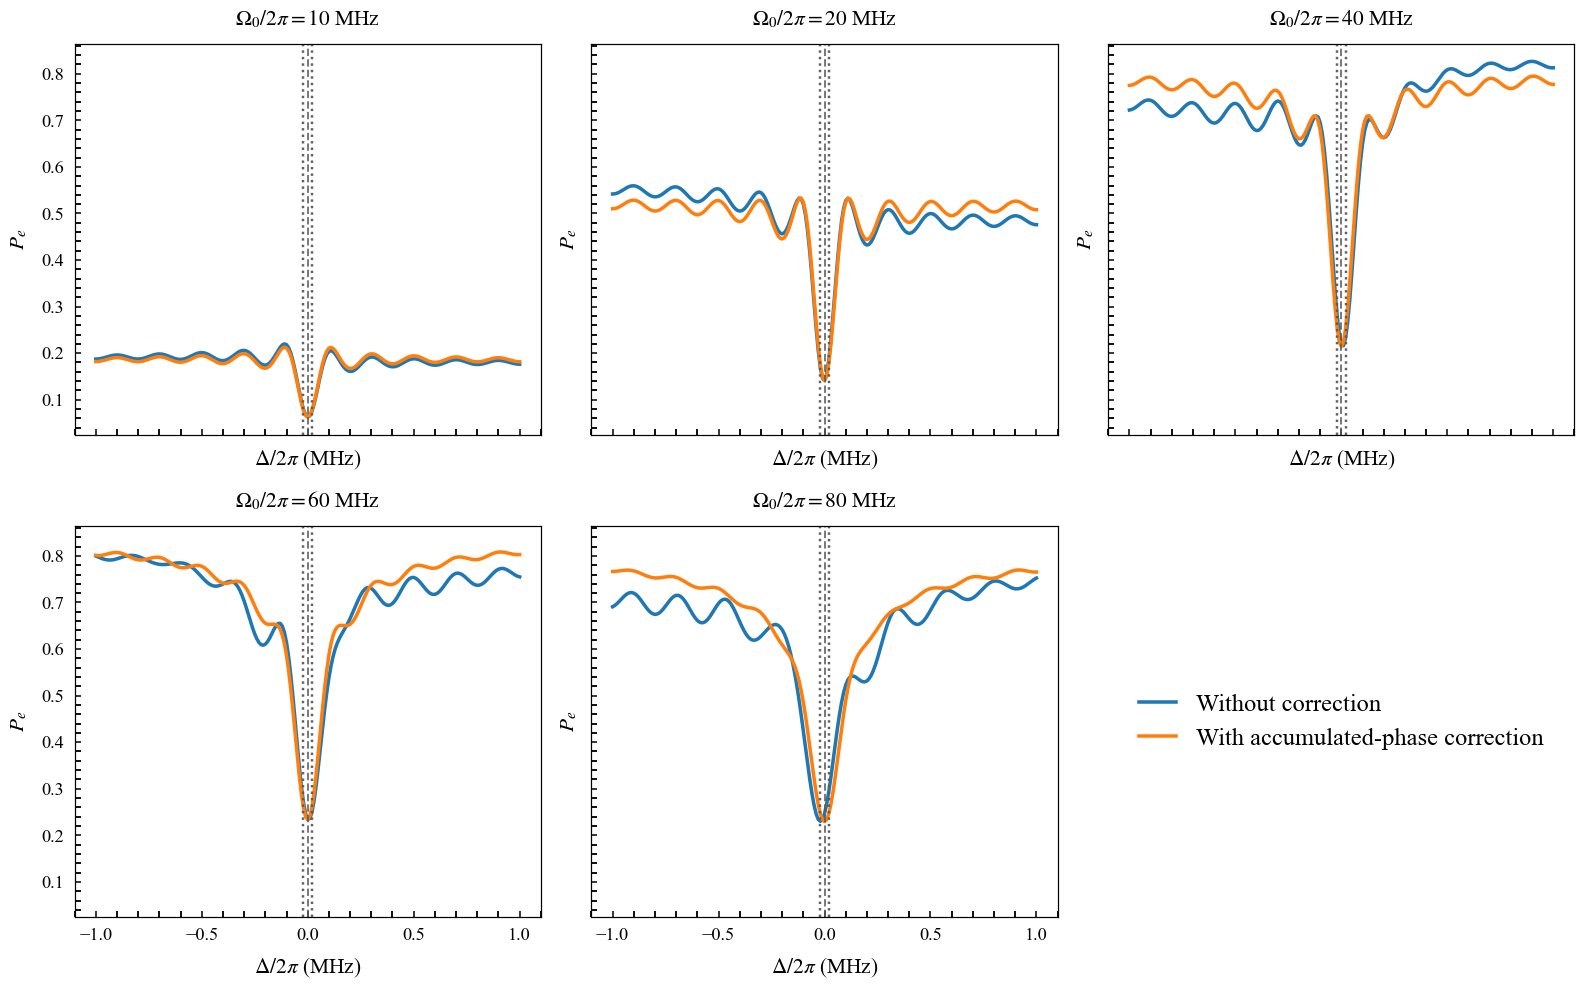

**Fitted f10 offsets and FWHM in T2 units**

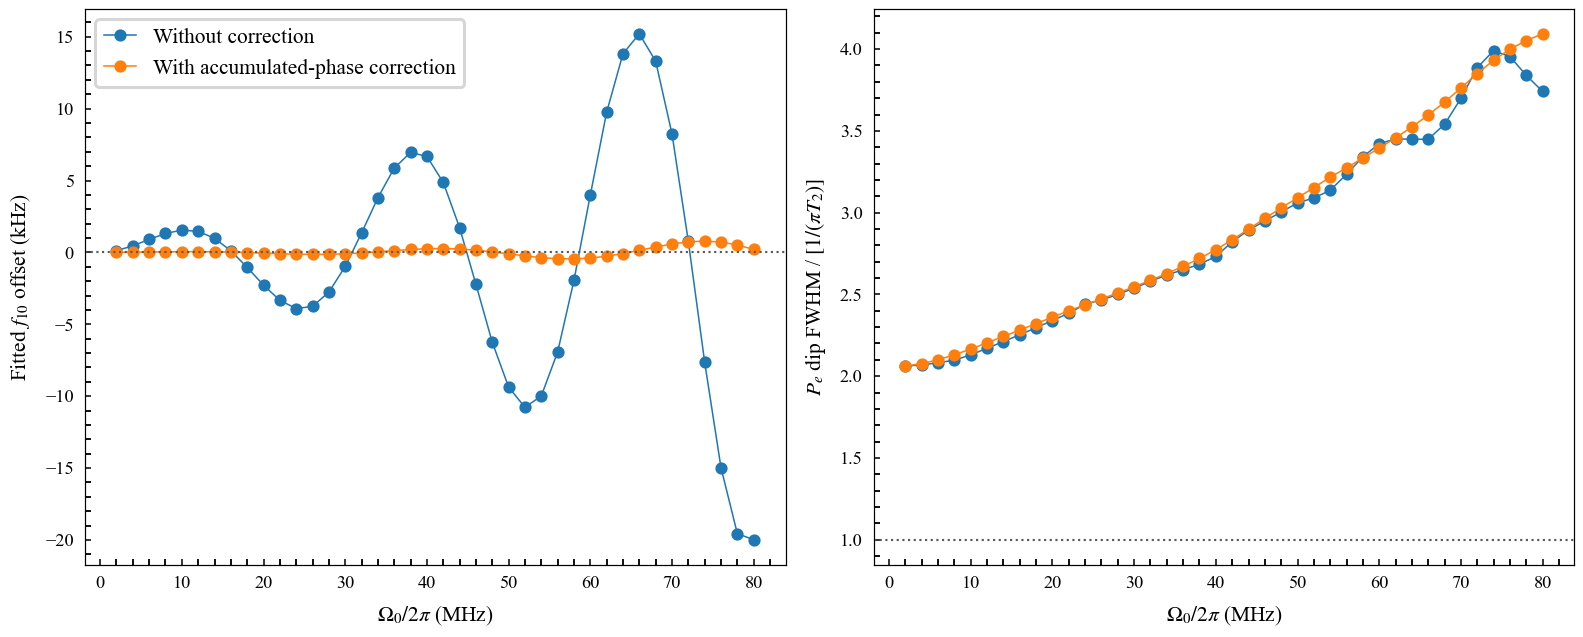

**Complete Pg, Pe, and Pf maps**

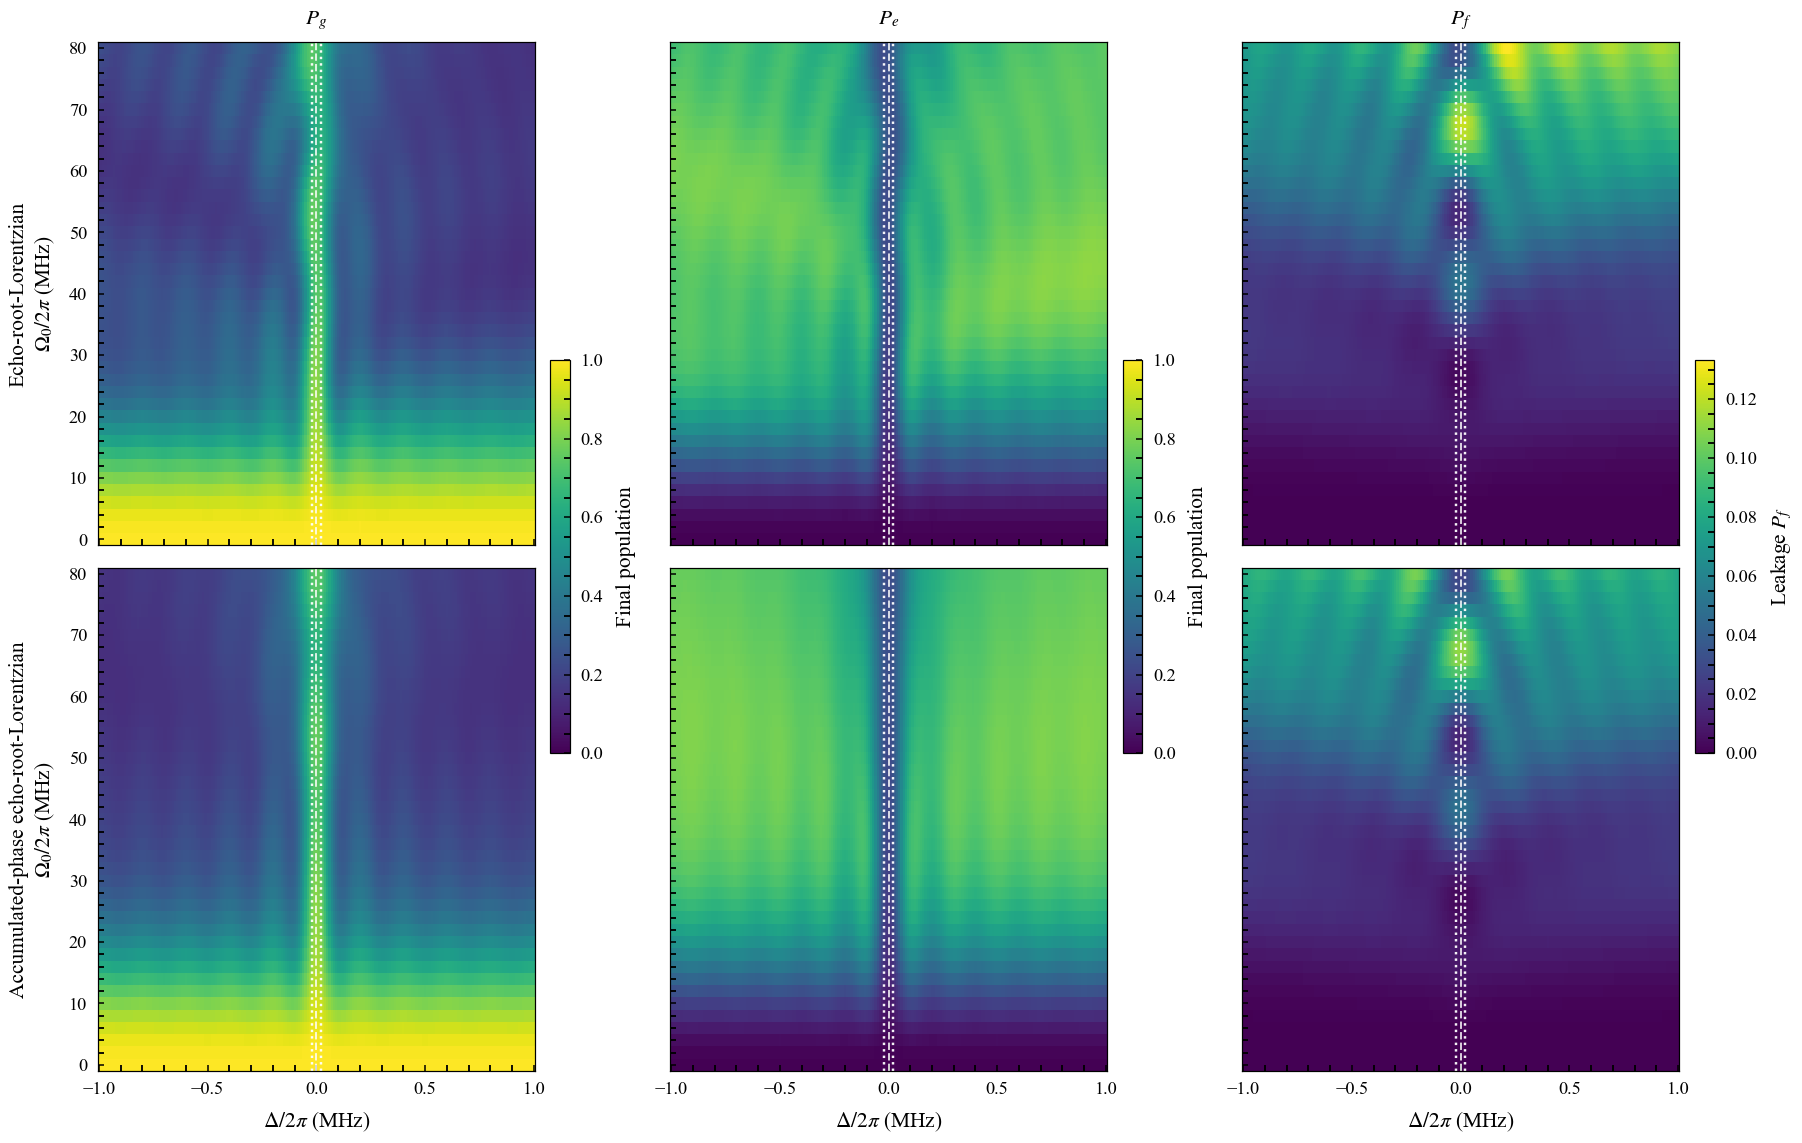

**Leakage difference and worst-case leakage**

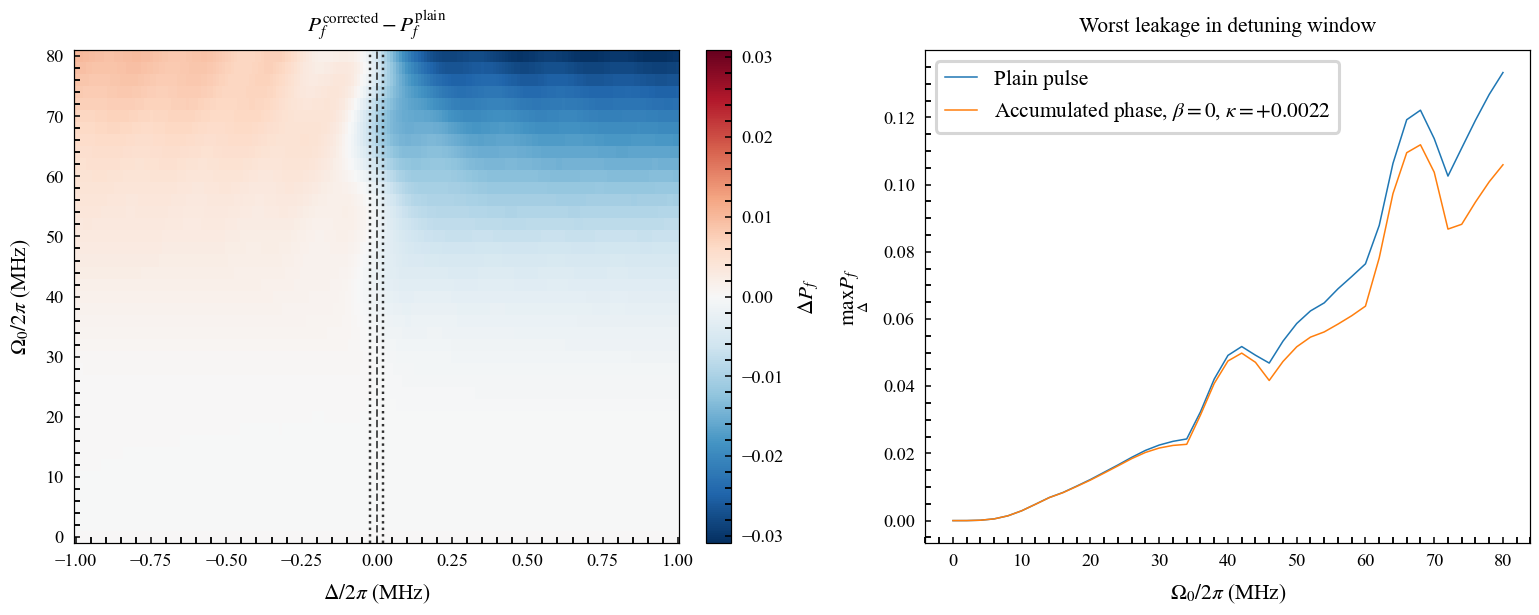

duration_us,rabi_mhz,plain_center_khz,corrected_center_khz,plain_fwhm_mhz,corrected_fwhm_mhz,plain_fwhm_t2,corrected_fwhm_t2,plain_max_leakage,corrected_max_leakage
10.0,2.0,0.12335700147808484,0.003455680957762359,0.08977867603807889,0.08977795080802878,2.061771092649703,2.0617544377109267,7.3727155320927626e-06,7.372036782915229e-06
10.0,4.0,0.45776681345421033,0.012967463693379078,0.09008198061505436,0.09043254932712597,2.0687364950890434,2.076787320390032,0.00011170066017680983,0.0001116595349258999
10.0,6.0,0.9038229205880661,0.026117676913337846,0.09067565265706283,0.09146190771587773,2.0823701986447545,2.1004265793272516,0.0005157126261333537,0.0005152855349886472
10.0,8.0,1.3193997217392786,0.03934271042638531,0.09135643940053559,0.09278795064188297,2.0980044950043477,2.1308792112115826,0.0014288493984927694,0.0014267462731570757
10.0,10.0,1.5499369531702984,0.048548868637584716,0.0927835495105687,0.0943250153082266,2.130778139044793,2.1661779662885277,0.0029308561035163152,0.002924115967346585
10.0,12.0,1.4629674211762729,0.049847957886683746,0.09452151200965585,0.09599407372338137,2.170690521348217,2.2045079633899585,0.004872454556237738,0.004856311899393815
10.0,14.0,0.9817322776710807,0.040340923427067986,0.09630914681974576,0.09766607551833942,2.211743630374847,2.2429055553330697,0.006863101028466645,0.00683210775257715
10.0,16.0,0.11234233926838981,0.01887500594623605,0.0981259409359433,0.09936971060175345,2.253466384099611,2.282029607083589,0.008366510518201793,0.0083169956966736
10.0,18.0,-1.0412524067342137,-0.013334873017957362,0.09999586238197126,0.10109137332348972,2.296409209201097,2.321567664310707,0.01027078540234316,0.010165394335251628
10.0,20.0,-2.2796395222793726,-0.052385436331963214,0.10191315262514544,0.10281197710364638,2.340439860732639,2.3610814028996585,0.012236416256537966,0.012063654680917434


### $L=20~\mu\mathrm{s}$

**Original and accumulated-phase-corrected pulse**

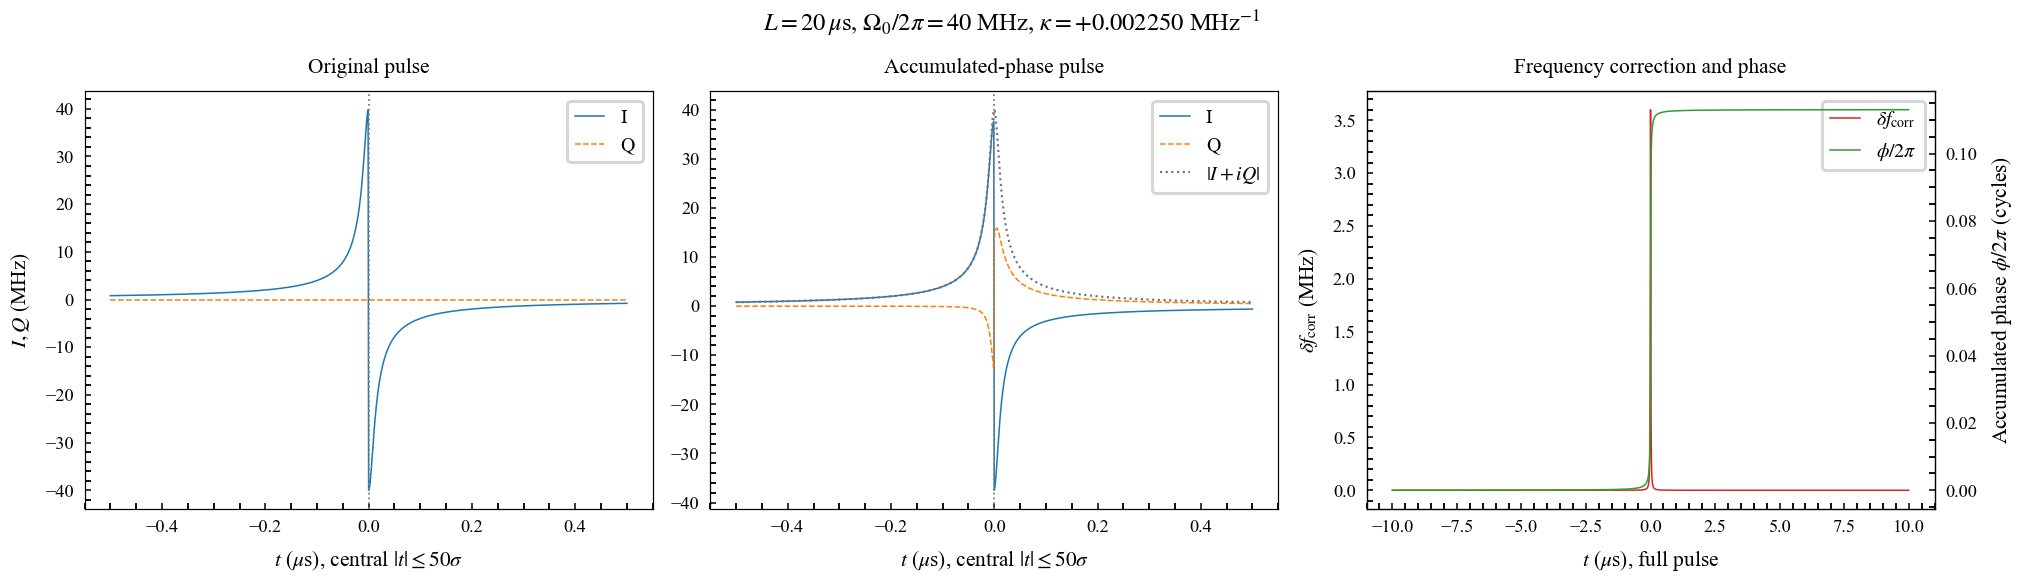

**Quadratic phase-coefficient optimization**

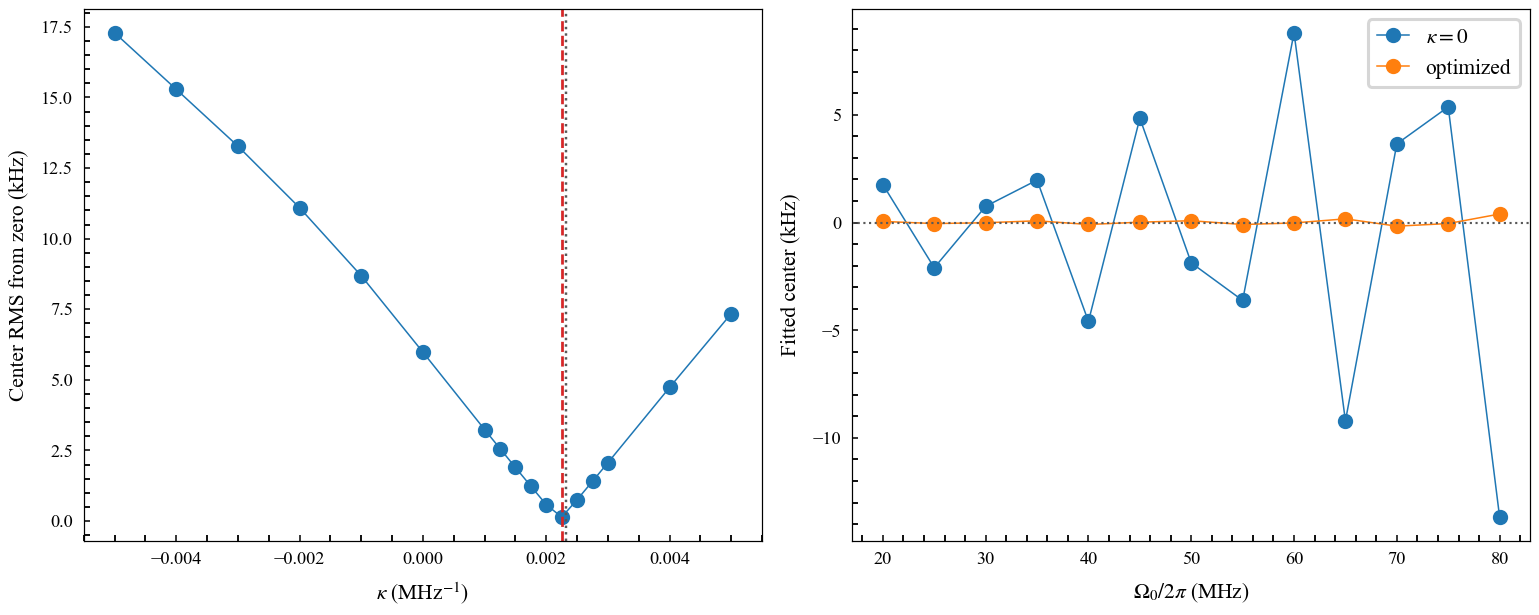

**Excited-state maps with T2-limit bounds**

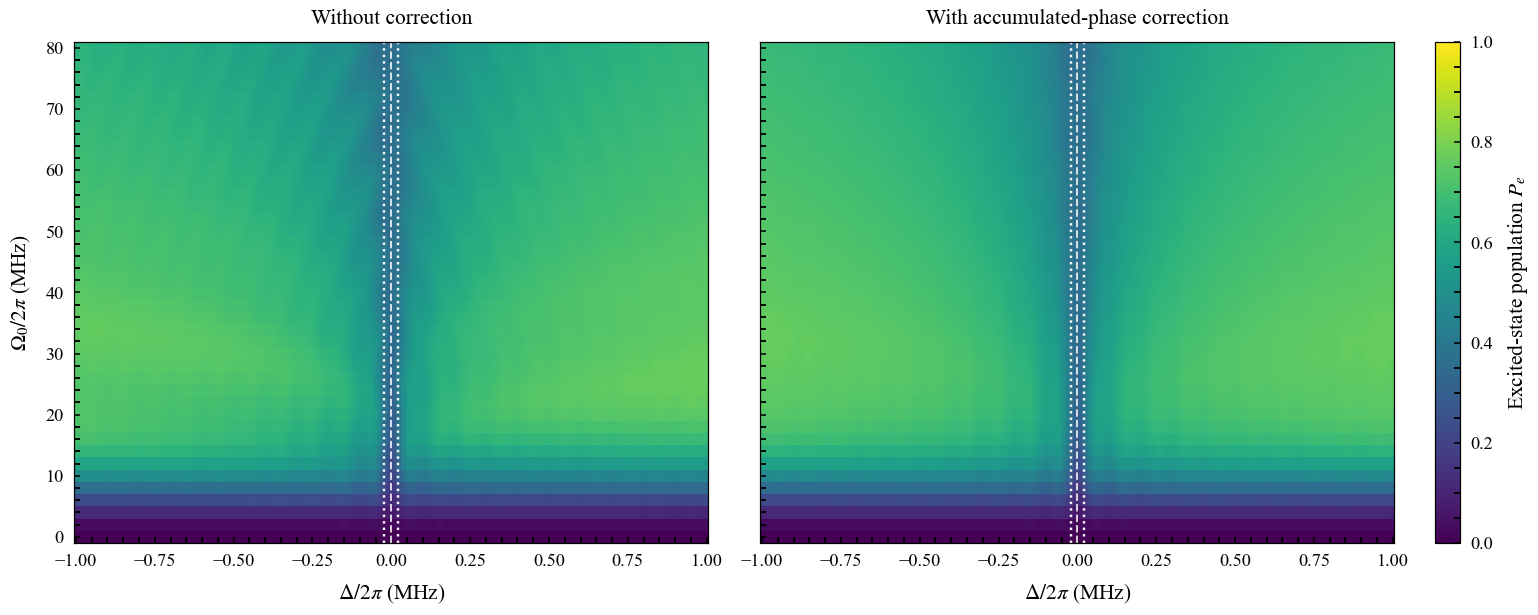

**One-dimensional detuning sweeps**

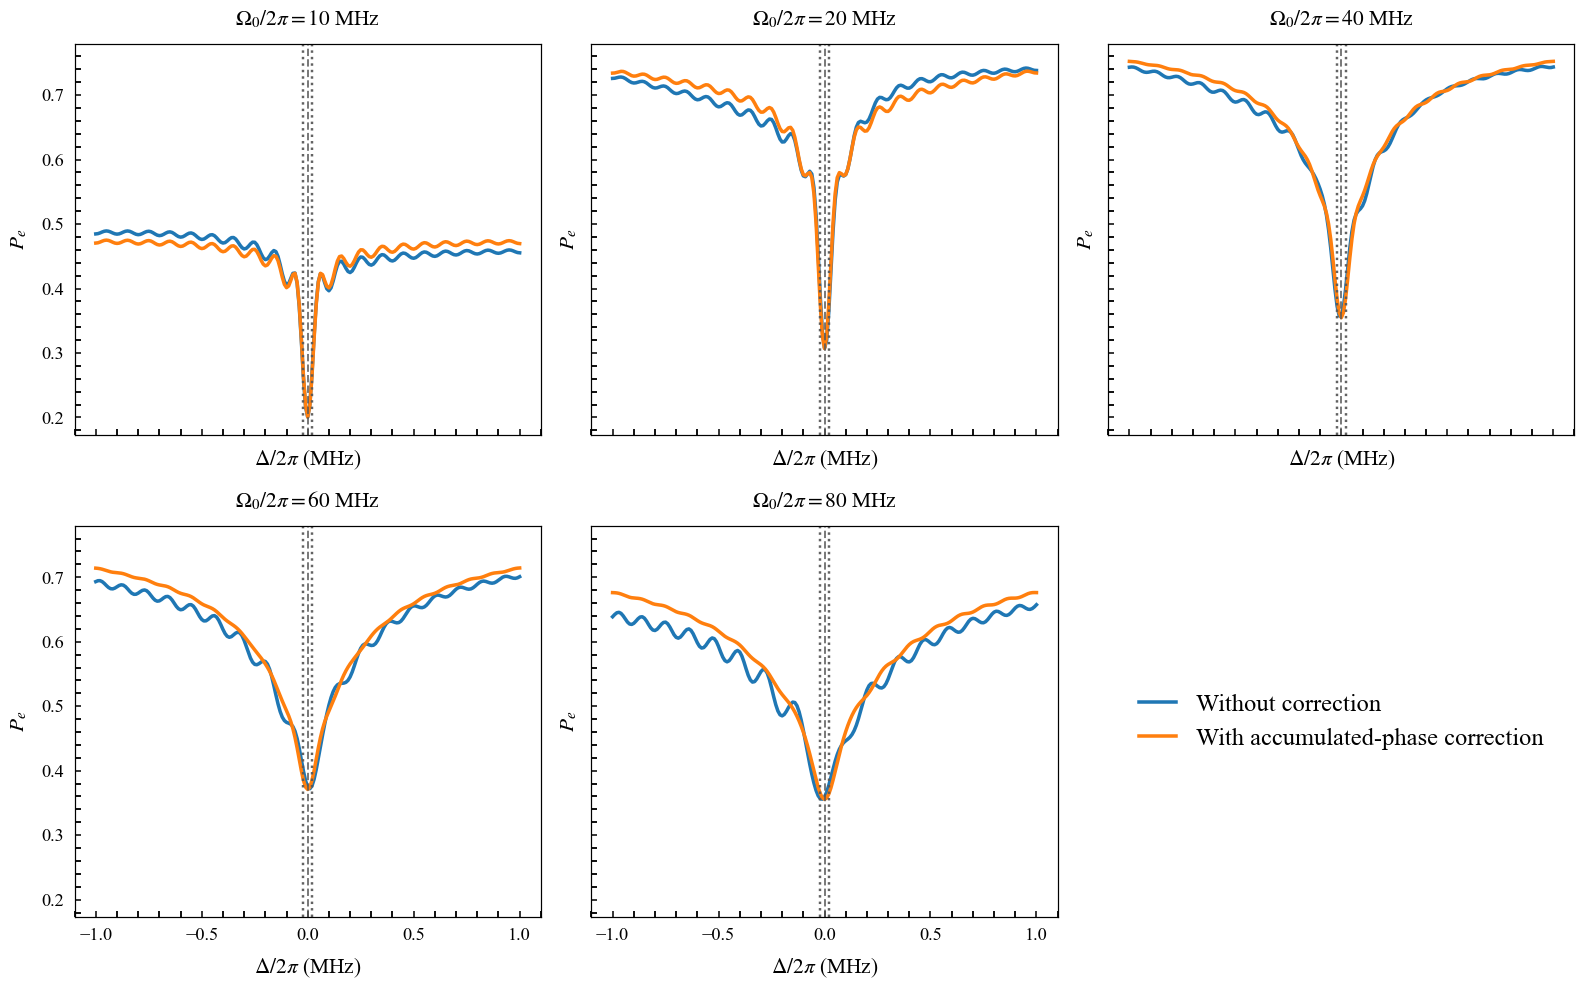

**Fitted f10 offsets and FWHM in T2 units**

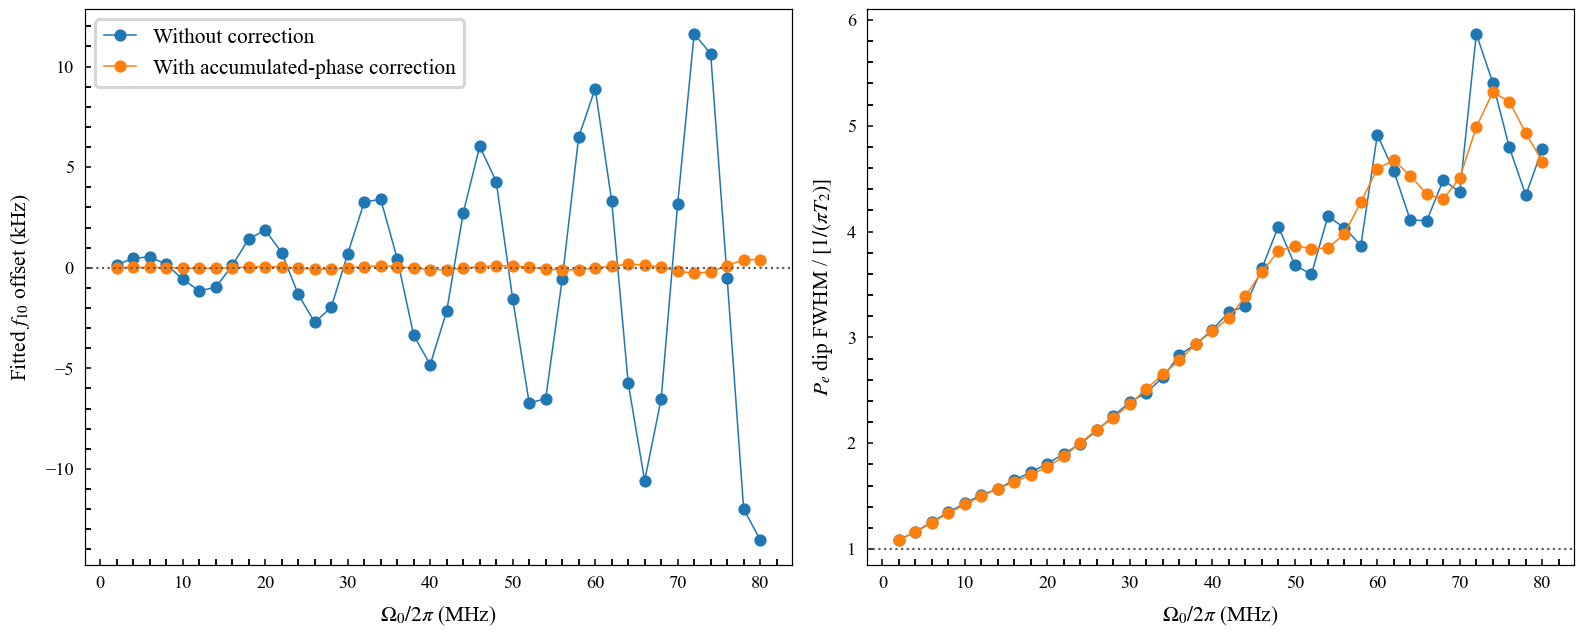

**Complete Pg, Pe, and Pf maps**

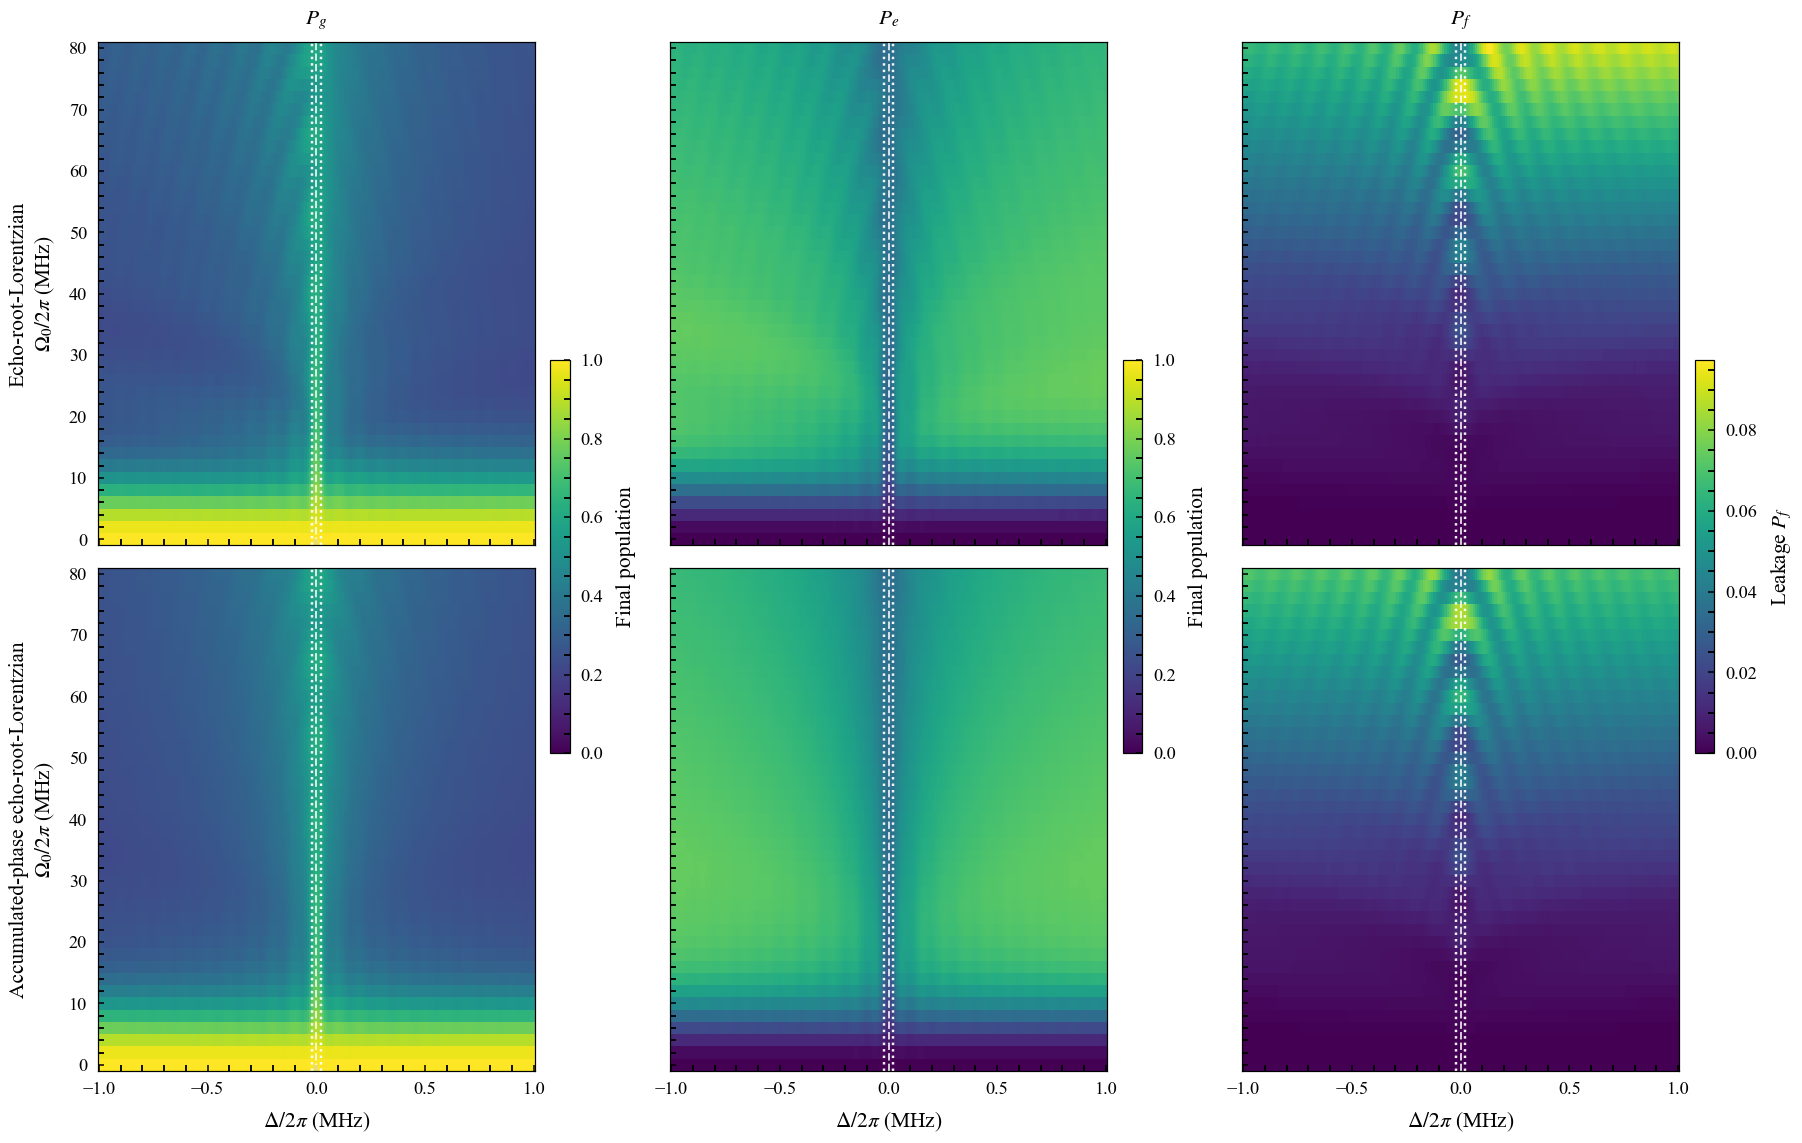

**Leakage difference and worst-case leakage**

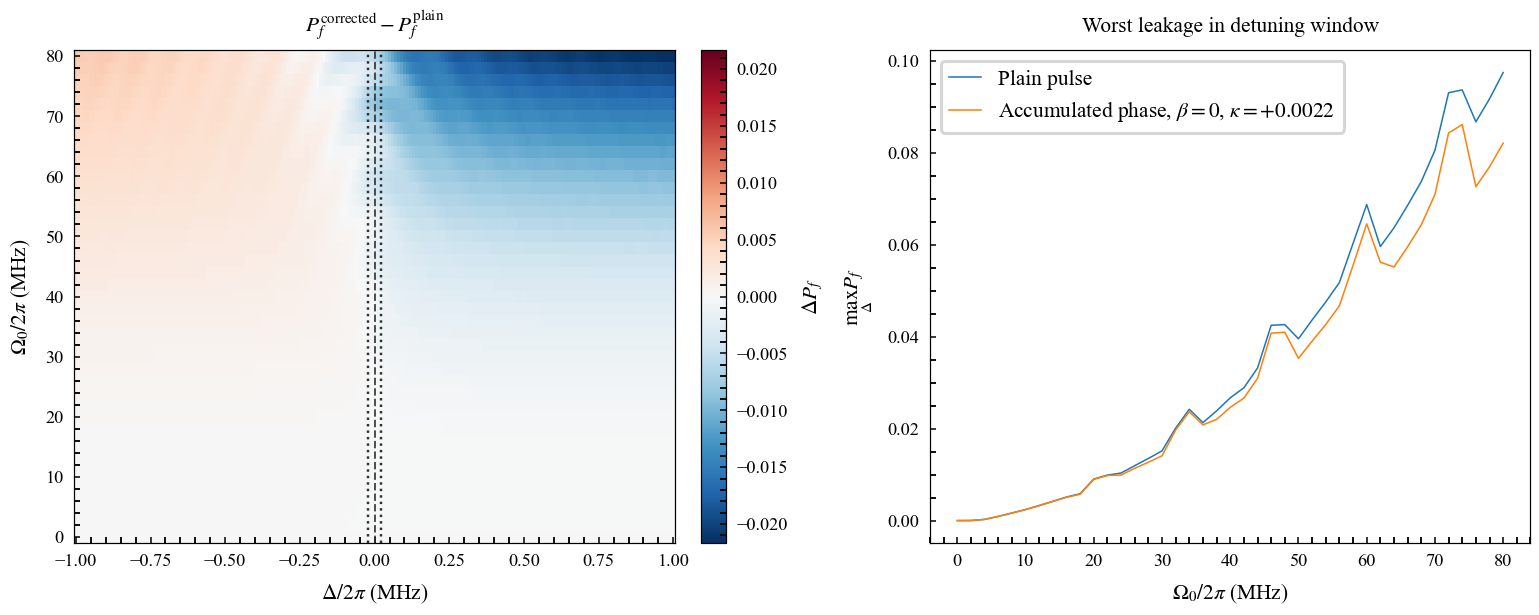

duration_us,rabi_mhz,plain_center_khz,corrected_center_khz,plain_fwhm_mhz,corrected_fwhm_mhz,plain_fwhm_t2,corrected_fwhm_t2,plain_max_leakage,corrected_max_leakage
20.0,2.0,0.1577014638966356,0.0044570487264908734,0.04738841490528464,0.047368111328956575,1.0882769527227802,1.0878106802336107,2.0015960666648685e-05,2.0014253291630954e-05
20.0,4.0,0.46085962678650294,0.013146962198461142,0.05061938990380639,0.05045846443257537,1.1624764302267772,1.158780769973173,0.00025962813434350797,0.0002595397273350104
20.0,6.0,0.5475997260629718,0.016016279278738596,0.05473280244650437,0.05439759285176691,1.2569411232578962,1.2492430207361416,0.0009102362459134295,0.0009095408180898053
20.0,8.0,0.1675681410838215,0.0058300508433174565,0.05864047998722442,0.05824702021833147,1.3466811032664663,1.33764528303138,0.0016478545484758895,0.0016456205242794078
20.0,10.0,-0.5699535335724071,-0.014996338096448342,0.062400953958626625,0.06193253989718539,1.4330405470792733,1.4222833983454186,0.002400861899848021,0.0023928647271198858
20.0,12.0,-1.1513680291491182,-0.03276249580979102,0.06582720067403386,0.06533948173972061,1.511724447821098,1.5005239618651849,0.0032732806478029744,0.0032574422845621414
20.0,14.0,-0.9685619293081629,-0.030277504662143302,0.06830276859789325,0.06837345486362591,1.5685759699034607,1.5701992829858806,0.004187715185146557,0.004162036436521077
20.0,16.0,0.11408879606660075,-0.0018553812001692027,0.07199875886041715,0.07118064634755589,1.6534545426143625,1.634666554152192,0.00512093217331312,0.005074748407119633
20.0,18.0,1.4377808351443302,0.036831430933179296,0.07512324046389267,0.07406142328613453,1.7252083947966925,1.7008237183970085,0.005839776919461834,0.005724581331238962
20.0,20.0,1.8720316807142667,0.05558368849793203,0.07872872445452098,0.07736165180856366,1.808008487145301,1.776613606006806,0.00902827479880198,0.008955618311547573


### $L=30~\mu\mathrm{s}$

**Original and accumulated-phase-corrected pulse**

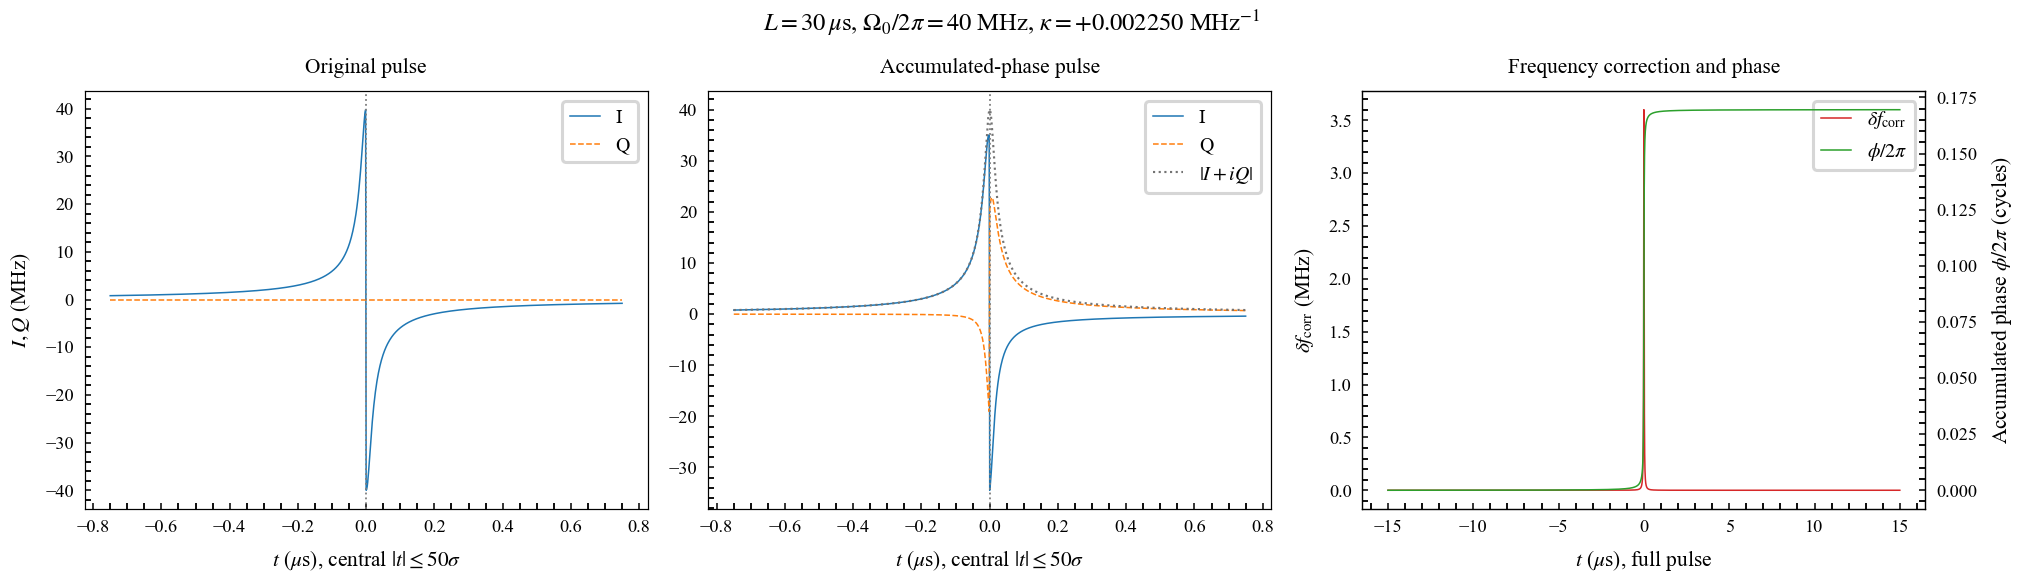

**Quadratic phase-coefficient optimization**

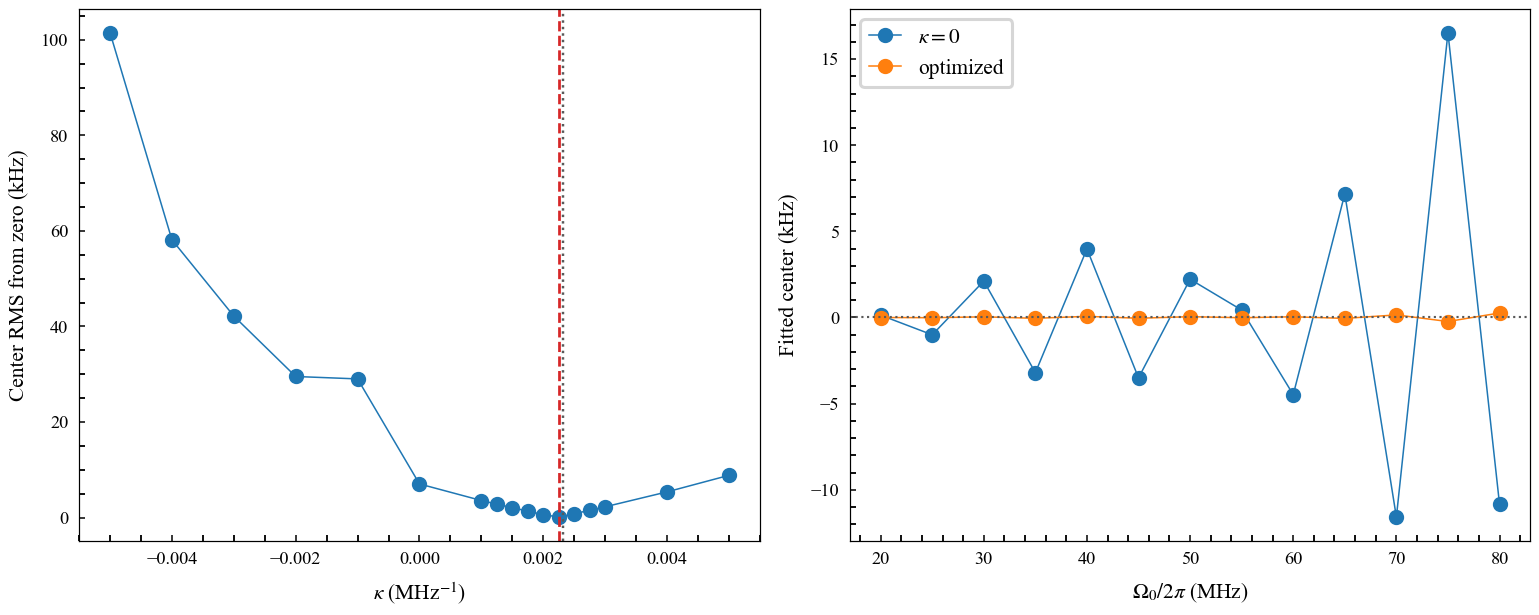

**Excited-state maps with T2-limit bounds**

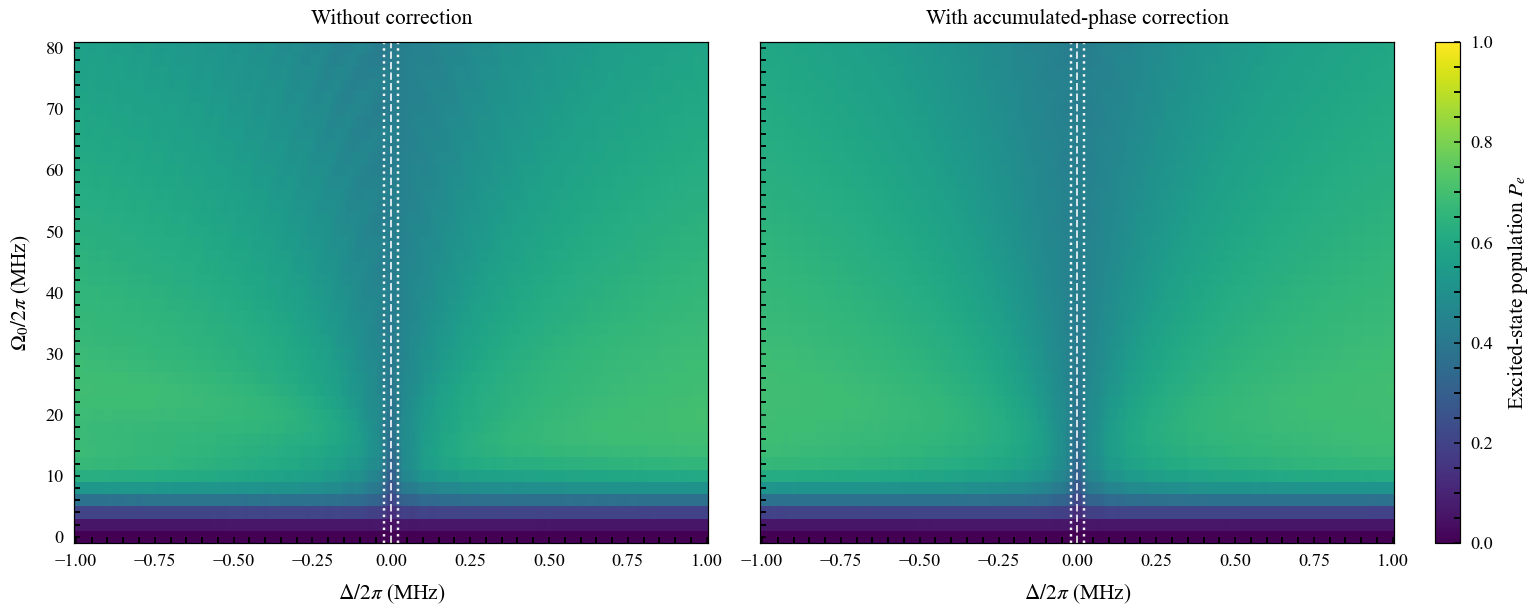

**One-dimensional detuning sweeps**

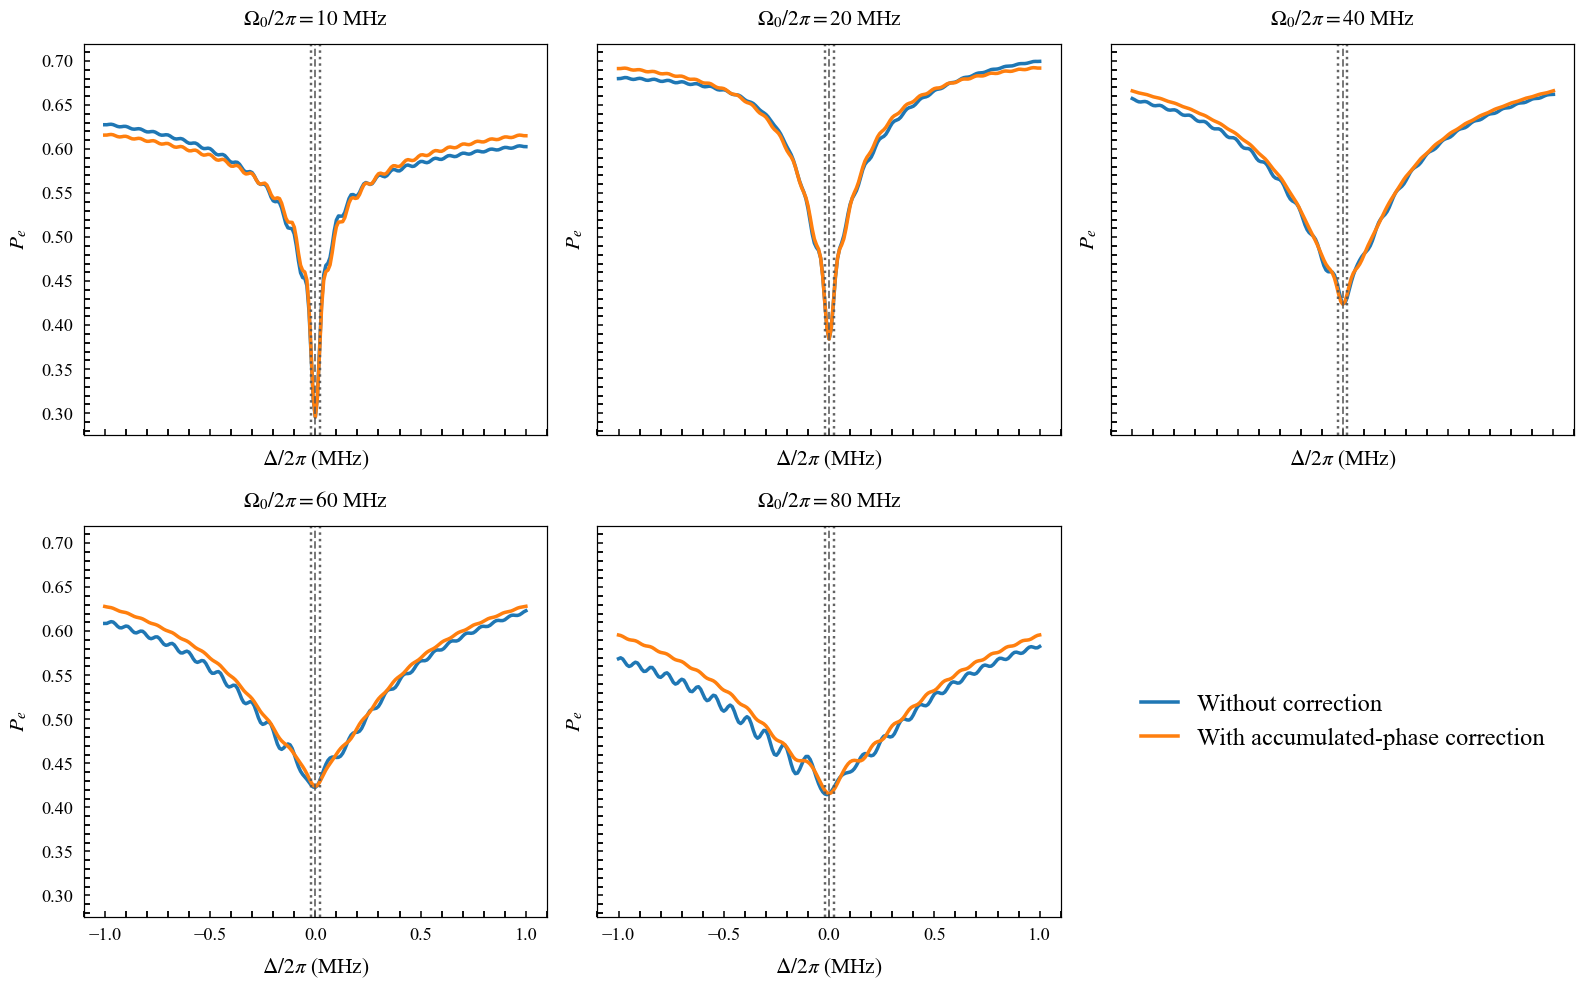

**Fitted f10 offsets and FWHM in T2 units**

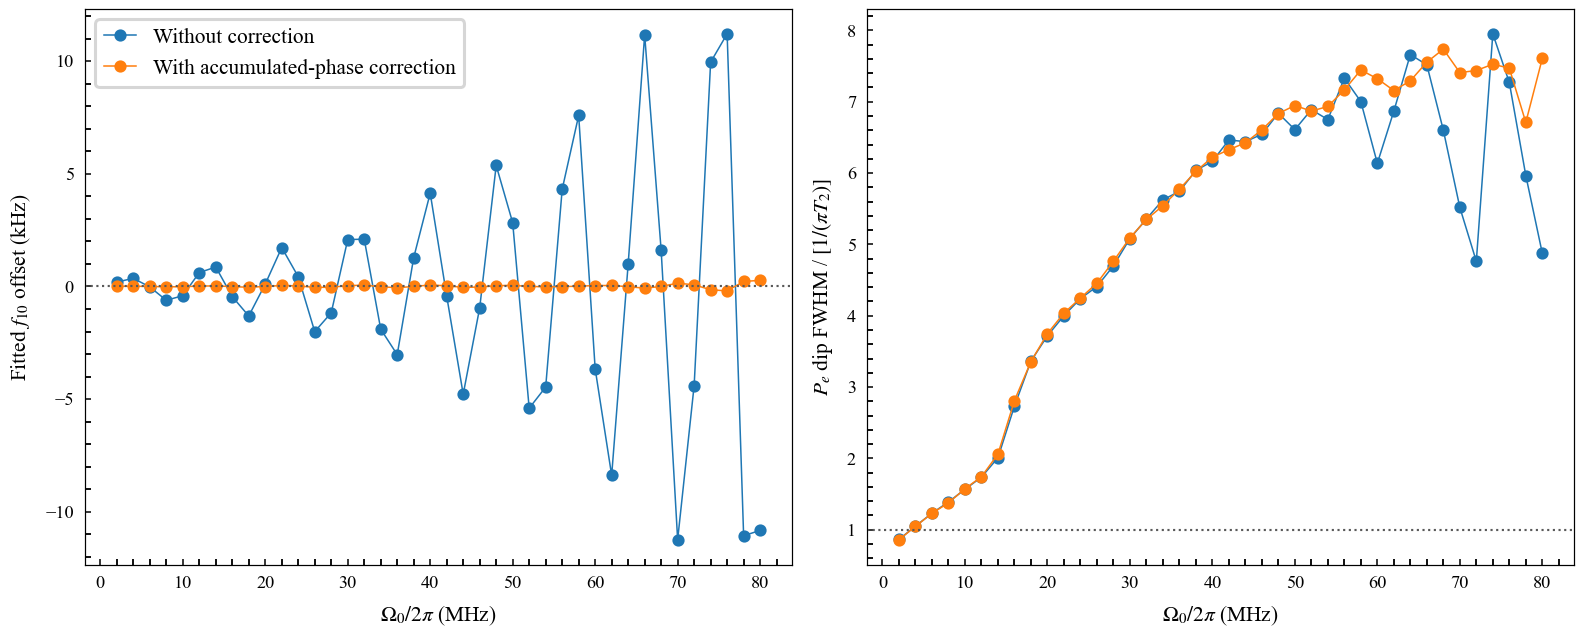

**Complete Pg, Pe, and Pf maps**

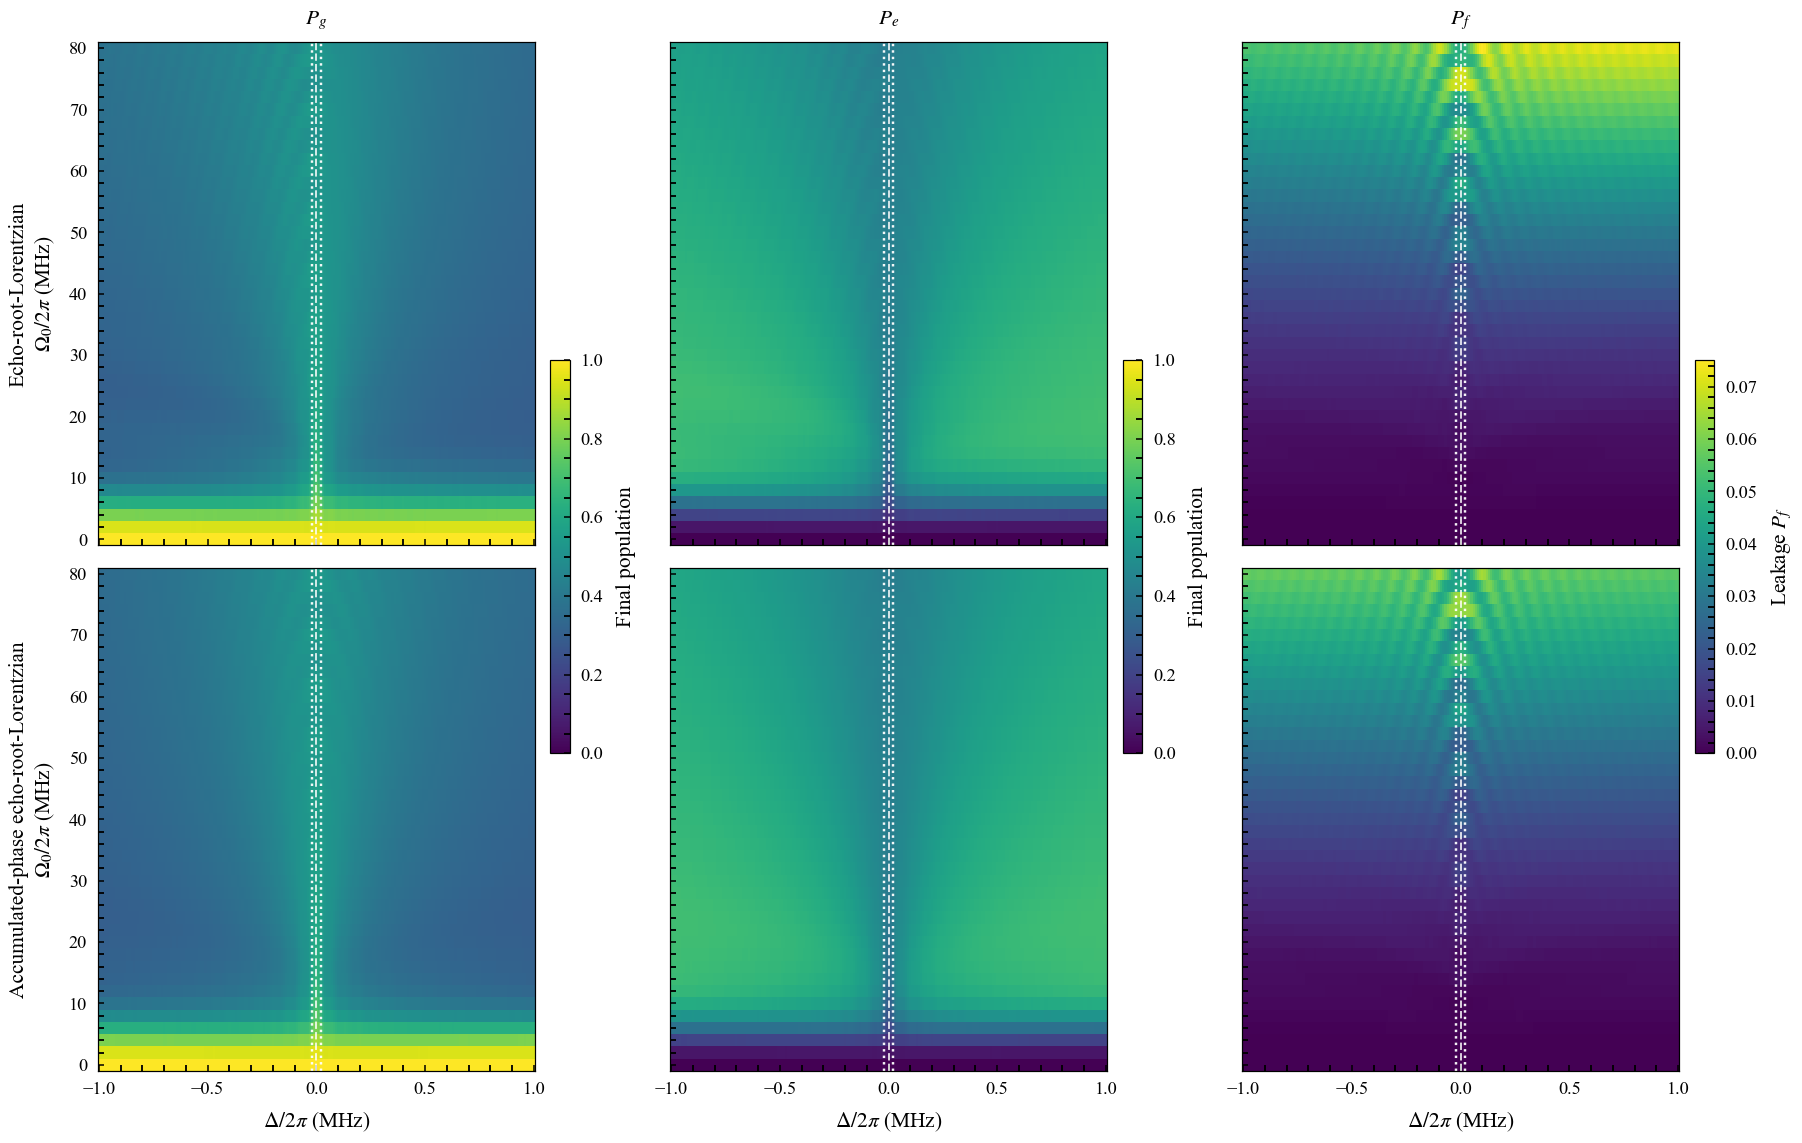

**Leakage difference and worst-case leakage**

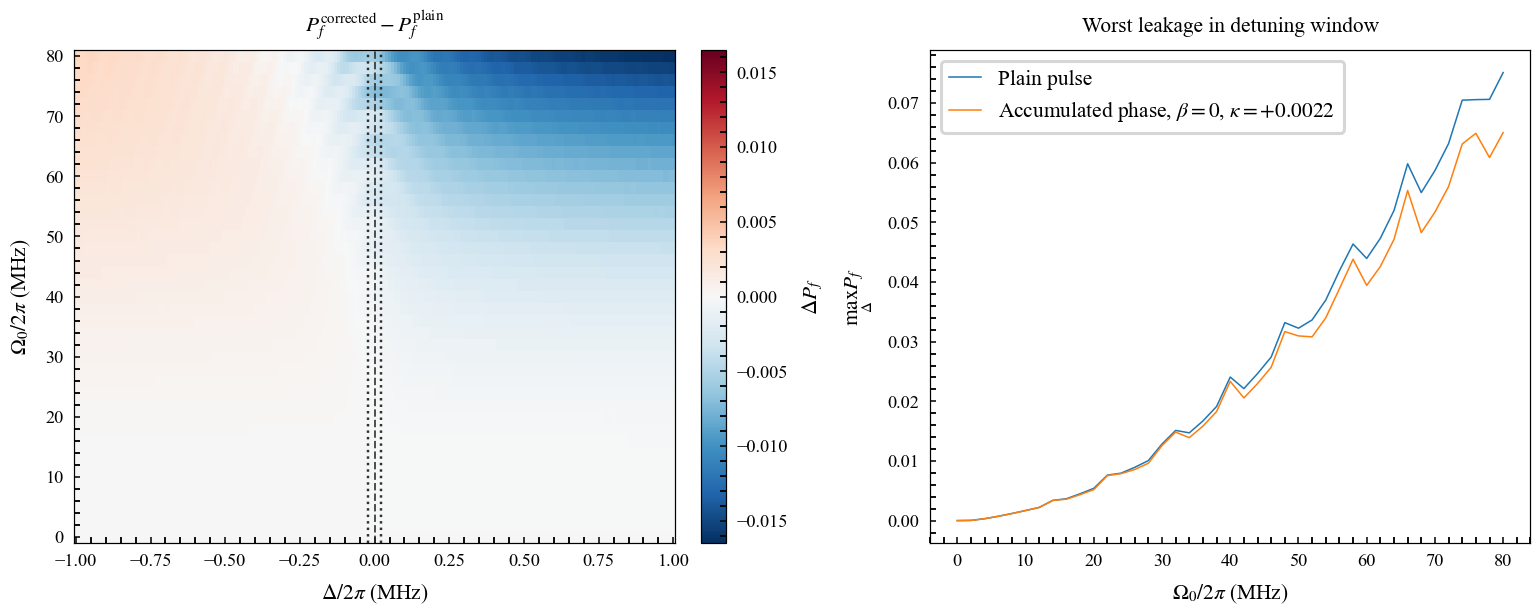

duration_us,rabi_mhz,plain_center_khz,corrected_center_khz,plain_fwhm_mhz,corrected_fwhm_mhz,plain_fwhm_t2,corrected_fwhm_t2,plain_max_leakage,corrected_max_leakage
30.0,2.0,0.1944773133809426,0.005469758671358691,0.03761342683485737,0.037456193685851215,0.8637939382255005,0.8601830723079671,3.130292073673289e-05,3.13002923854906e-05
30.0,4.0,0.36033391881171506,0.010260588942296431,0.04572290624878327,0.04561668862063514,1.050028475978972,1.0475891836557845,0.0003157397902917789,0.00031563413527298364
30.0,6.0,-0.02028888557535591,-0.00021190763057758947,0.05362632286881364,0.0535344722237287,1.2315307729546416,1.229421419005191,0.0007227880280309491,0.0007217622969504499
30.0,8.0,-0.613061613862698,-0.017088467222445138,0.060482619858899904,0.05996214408889086,1.3889859233378496,1.3770331752646425,0.001184825966040217,0.0011820257245780575
30.0,10.0,-0.4099697333228846,-0.012287869699723328,0.06820009990769707,0.06855803935319338,1.566218179090452,1.5744382735963047,0.0016891163741019977,0.0016839482593218908
30.0,12.0,0.6159768824617611,0.01645666342621813,0.07565522403046712,0.07588911507120287,1.7374254199047783,1.7427967375483375,0.0022096582004008927,0.0021991440691915064
30.0,14.0,0.8619367217763183,0.02584275727933267,0.08749589475303256,0.08969792162304903,2.0093469238821213,2.0599165640928128,0.0033906486001153316,0.0033773780086934855
30.0,16.0,-0.4504789490817406,-0.008493894007941346,0.11900035742369994,0.1223403384927972,2.7328482416816127,2.8095510482070867,0.0036711664605862354,0.0035864873761800634
30.0,18.0,-1.3106961025311967,-0.035590739435426594,0.14646576419112683,0.1461841675453891,3.3635924698202437,3.3571255909399746,0.0045024678858900675,0.004353374607617807
30.0,20.0,0.10590548769029558,-0.0025001167418540874,0.1619250588933352,0.16324837529133798,3.718615826549708,3.749005843603137,0.00540899197183373,0.0051874345730325835


In [4]:
amplitude_metrics = read_csv_rows(AMPLITUDE_CSV)
figure_specs = (
    ('00_pulse_waveform_comparison.png', 'Original and accumulated-phase-corrected pulse'),
    ('01_kappa_optimization.png', 'Quadratic phase-coefficient optimization'),
    ('02_pe_maps.png', 'Excited-state maps with T2-limit bounds'),
    ('03_pe_1d_detuning_sweeps.png', 'One-dimensional detuning sweeps'),
    ('04_f10_fwhm.png', 'Fitted f10 offsets and FWHM in T2 units'),
    ('05_all_populations.png', 'Complete Pg, Pe, and Pf maps'),
    ('06_leakage.png', 'Leakage difference and worst-case leakage'),
)

for duration_us in DURATIONS_US:
    display(Markdown(f'### $L={duration_us}~\\mu\\mathrm{{s}}$'))
    row = next(row for row in summary if float(row['duration_us']) == duration_us)
    display(HTML(
        f'<b>κ:</b> {float(row["kappa_mhz_inv"]):+.6f} MHz⁻¹ &nbsp; '
        f'<b>max |center|:</b> {float(row["plain_max_center_khz"]):.2f} → '
        f'{float(row["corrected_max_center_khz"]):.2f} kHz &nbsp; '
        f'<b>corrected FWHM/T₂:</b> {float(row["corrected_fwhm_t2_min"]):.2f}–'
        f'{float(row["corrected_fwhm_t2_max"]):.2f}'
    ))
    duration_dir = FIGURE_DIR / f'{duration_us:g}us'
    for filename, caption in figure_specs:
        display(Markdown(f'**{caption}**'))
        display(Image(filename=str(duration_dir / filename)))
    duration_rows = [row for row in amplitude_metrics if float(row['duration_us']) == duration_us]
    display(html_table(duration_rows))

## Self-contained report

In [5]:
display(HTML(
    f'<p><a href="{REPORT_PATH.as_uri()}" target="_blank">Open the tabbed duration report</a></p>'
    f'<p>Raw data: <code>{DATA_DIR}</code></p>'
))